In [ ]:
!pip install XlsxWriter -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.3 MB/s eta 0:00:00


=== Validation (Jan–Jul 2025) — Overall ===
MAE           9404.924167
RMSE         22645.097407
R2               0.936663
MAPE_pos%       67.395649
dtype: float64

=== Top 10 categories by RMSE (lower is better) ===
                Jerarquia           MAE          RMSE        R2   MAPE_pos%
7                   OTROS    496.808983   1017.550808 -0.753907  218.702988
0    BELLEZA Y ACCESORIOS   2676.113051   4304.352292  0.797320   46.198250
5         ENTRETENIMIENTO   3127.687883   5406.224861  0.442199  104.965452
8  SERVICIOS y TECNOLOGÍA   4573.585662   7165.665615  0.861115   42.608951
3                 DEPORTE   7446.460141  14774.031287  0.682959   68.035318
4          DISCOTECAS/BAR   6983.731916  18405.955134  0.846287  376.605522
2            DECO - HOGAR  11562.907482  19082.674035  0.627822   39.340296
6                    MODA  11209.946778  27523.134209  0.663810   52.010458
9      SUPERMERCADO Y TxD  24633.695702  36960.864821  0.955361   15.930694
1                  COMID

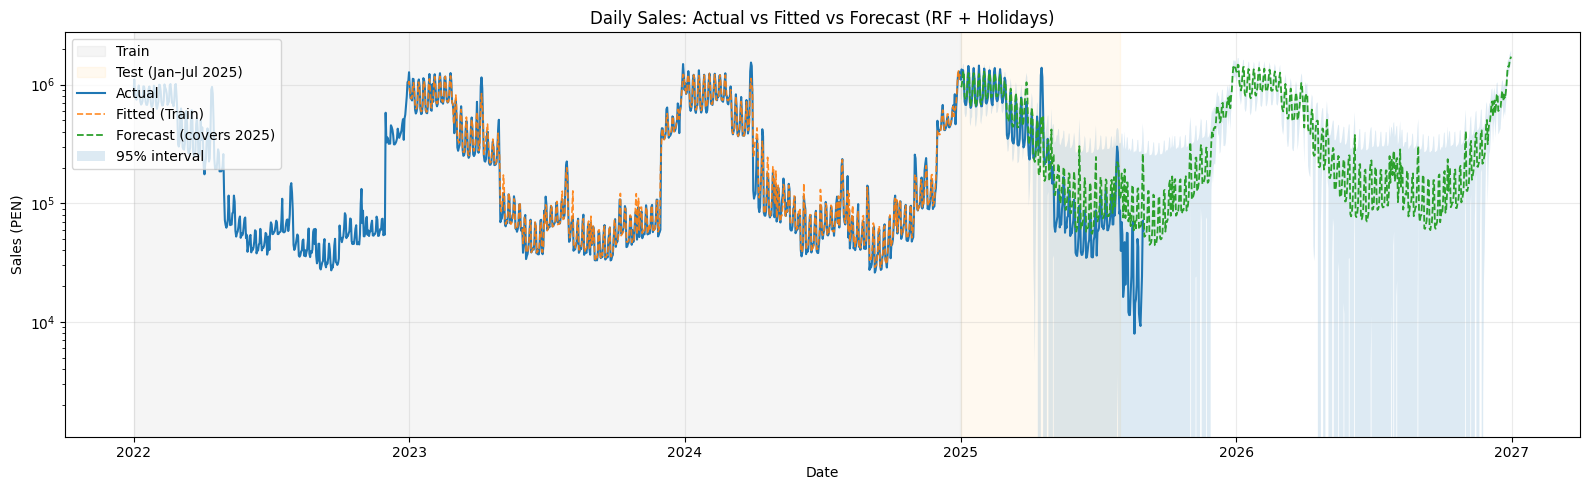


Saved: RF_Forecast_by_Category_2025_full_and_2026.xlsx


In [ ]:
# @title Mall Sales by Category — Random Forest (Daily) — Full 2025 Forecast + Plot (Test = Jan–Jul 2025)

from __future__ import annotations
import warnings, math
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# =========================
# ======= CONFIG ==========
# =========================
INPUT_XLSX      = "Ventas Reales hasta Agosto 31 2025.xlsx"
INPUT_SHEET     = "Detalle de Ventas x Local"
USECOLS         = "D,H,K"   # D=Fecha, H=Monto, K=Jerarquia (categoría)

TRAIN_END_DATE  = pd.Timestamp("2024-12-31")           # train ≤ 2024
VALID_END_DATE  = pd.Timestamp("2025-08-31")           # validation/test ends Aug-2025 (exclude Aug)
FORECAST_START  = pd.Timestamp("2025-01-01")
FORECAST_END    = pd.Timestamp("2026-12-31")           # set to 2025-12-31 if only 2025
LAGS            = [7, 14, 28, 56, 364]
ROLLS           = [7, 28]
RANDOM_STATE    = 42
N_JOBS          = -1
LOG_SCALE       = True   # False for linear axis

# Optional holidays
try:
    import holidays
    HOL_AVAILABLE = True
except Exception:
    HOL_AVAILABLE = False

# =========================
# ====== LOAD DATA ========
# =========================
raw = pd.read_excel(
    INPUT_XLSX,
    sheet_name=INPUT_SHEET,
    parse_dates=["Fecha"],
    usecols=USECOLS
)
raw.columns = ["Fecha", "Monto_Soles", "Jerarquia"]

raw["Fecha"] = pd.to_datetime(raw["Fecha"]).dt.floor("D")
raw["Monto_Soles"] = pd.to_numeric(raw["Monto_Soles"], errors="coerce").fillna(0.0)
raw["Jerarquia"] = raw["Jerarquia"].astype("string").fillna("SIN_CATEGORIA")

# Aggregate to daily per category
df = (raw.groupby(["Fecha", "Jerarquia"], as_index=False)["Monto_Soles"]
          .sum()
          .rename(columns={"Fecha":"ds", "Monto_Soles":"y"})
          .sort_values(["ds","Jerarquia"])
          .reset_index(drop=True))
if df.empty:
    raise ValueError("No data loaded. Check sheet name / columns / usecols.")

first_ds = df["ds"].min()
last_obs = df["ds"].max()

# =========================
# === COMPLETE CALENDAR ===
# =========================
cats = df["Jerarquia"].dropna().unique()
calendar = pd.MultiIndex.from_product(
    [pd.date_range(first_ds, FORECAST_END, freq="D"), cats],
    names=["ds","Jerarquia"]
).to_frame(index=False)

full = (calendar.merge(df, on=["ds","Jerarquia"], how="left")
               .sort_values(["ds","Jerarquia"])
               .reset_index(drop=True))

full["y_obs"] = full["y"]        # keep raw observations (truth)
full["y"] = full["y"].fillna(0)  # modeling series (we'll overwrite for forecasts)

# =========================
# == CALENDAR FEATURES ====
# =========================
def add_calendar_features(_df: pd.DataFrame) -> pd.DataFrame:
    out = _df.copy()
    out["dow"]            = out["ds"].dt.weekday
    out["is_weekend"]     = (out["dow"] >= 5).astype(int)
    out["month"]          = out["ds"].dt.month
    out["dom"]            = out["ds"].dt.day
    out["weekofyear"]     = out["ds"].dt.isocalendar().week.astype(int)
    out["is_month_end"]   = out["ds"].dt.is_month_end.astype(int)
    out["is_month_start"] = out["ds"].dt.is_month_start.astype(int)
    # cyclic seasonality
    doy = out["ds"].dt.dayofyear.astype(int)
    out["sin_doy"] = np.sin(2*np.pi*doy/365.25)
    out["cos_doy"] = np.cos(2*np.pi*doy/365.25)
    # holidays (Peru)
    if HOL_AVAILABLE:
        years = list(range(out["ds"].dt.year.min(), out["ds"].dt.year.max()+1))
        pe_holidays = holidays.country_holidays("PE", years=years)
        hol_days = pd.to_datetime(list(pe_holidays))
        out["is_holiday"]  = out["ds"].isin(hol_days).astype(int)
        out["is_pre_hol"]  = out["ds"].shift(-1).isin(hol_days).astype(int)
        out["is_post_hol"] = out["ds"].shift(1).isin(hol_days).astype(int)
    else:
        out["is_holiday"]  = 0
        out["is_pre_hol"]  = 0
        out["is_post_hol"] = 0
    return out

full = add_calendar_features(full)

# =========================
# === LAGS & ROLLINGS =====
# =========================
def add_lag_rolling(_df: pd.DataFrame, lags, rolls) -> pd.DataFrame:
    out = _df.sort_values(["Jerarquia","ds"]).copy()
    grp = out.groupby("Jerarquia", group_keys=False)
    for L in lags:
        out[f"lag_{L}"] = grp["y"].shift(L)
    for W in rolls:
        out[f"rollmean_{W}"] = grp["y"].shift(1).rolling(
            W, min_periods=max(2, math.ceil(W/2))
        ).mean()
    return out

full = add_lag_rolling(full, LAGS, ROLLS)

# =========================
# ===== SPLITS/MASKS ======
# =========================
observed_mask = full["ds"] <= last_obs
train_mask    = (full["ds"] <= min(TRAIN_END_DATE, last_obs)) & observed_mask
valid_mask    = (
    (full["ds"] >  min(TRAIN_END_DATE, last_obs)) &
    (full["ds"] <= min(VALID_END_DATE, last_obs)) &
    observed_mask
)

# Features
CAL_FEATS   = ["dow","is_weekend","month","dom","weekofyear","is_month_end","is_month_start",
               "sin_doy","cos_doy","is_holiday","is_pre_hol","is_post_hol"]
LAG_FEATS   = [f"lag_{L}" for L in LAGS]
ROLL_FEATS  = [f"rollmean_{W}" for W in ROLLS]
FEATURES    = CAL_FEATS + LAG_FEATS + ROLL_FEATS + ["Jerarquia"]

def drop_na_feature_rows(df_in, mask):
    cols_needed = LAG_FEATS + ROLL_FEATS
    ok = mask & (~df_in[cols_needed].isna().any(axis=1))
    return df_in.loc[ok].copy()

train_df = drop_na_feature_rows(full, train_mask)
valid_df = drop_na_feature_rows(full, valid_mask)

X_train = train_df[FEATURES].copy()
y_train = train_df["y"].values
X_valid = valid_df[FEATURES].copy()
y_valid = valid_df["y"].values

# =========================
# ======== MODEL ==========
# =========================
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

cat_col = ["Jerarquia"]
num_cols = [c for c in FEATURES if c not in cat_col]

pre = ColumnTransformer(
    transformers=[
        ("cat", make_ohe(), cat_col),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
"""
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)
model = Pipeline(steps=[("prep", pre), ("rf", rf)])
model.fit(X_train, y_train)
"""
# --- Smoothed RF preset that often lowers MAPE on daily sales ---
rf_kwargs = dict(
    n_estimators=1000,
    max_depth=14,             # try 10–18
    min_samples_leaf=20,      # try 10–60
    max_features=0.5,         # try 0.3–0.7 or "sqrt"
    bootstrap=True,
    max_samples=0.7,          # try 0.5–0.9; needs bootstrap=True
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
)

# Criterion: prefer "poisson" (counts/positive targets); else fall back to MAE-like
try:
    rf = RandomForestRegressor(criterion="poisson", **rf_kwargs)
    # quick sanity: y must be >= 0 for Poisson
    if (y_train < 0).any():
        raise ValueError("Negative targets not allowed for Poisson")
except Exception:
    rf = RandomForestRegressor(criterion="absolute_error", **rf_kwargs)

model = Pipeline(steps=[("prep", pre), ("rf", rf)])
model.fit(X_train, y_train)
valid_pred = model.predict(X_valid)
overall = metrics(y_valid, valid_pred)
print("New validation (Jan–Jul 2025) — Overall:", overall)



# =========================
# ===== VALIDATION ========
# =========================
def metrics(y_true, y_pred) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    pos = y_true > 0
    mape = (np.mean(np.abs((y_true[pos] - y_pred[pos]) / y_true[pos])) * 100.0) if pos.any() else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_pos%": mape}

valid_pred = model.predict(X_valid)
overall = metrics(y_valid, valid_pred)

# Per-category metrics (Jan–Jul 2025 only)
percat_rows = []
for cat in sorted(valid_df["Jerarquia"].unique()):
    m = valid_df["Jerarquia"] == cat
    if m.sum() == 0:
        continue
    mtr = metrics(y_valid[m], valid_pred[m])
    percat_rows.append({"Jerarquia": cat, **mtr})
percat_df = pd.DataFrame(percat_rows).sort_values("RMSE")

print("=== Validation (Jan–Jul 2025) — Overall ===")
print(pd.Series(overall))
print("\n=== Top 10 categories by RMSE (lower is better) ===")
print(percat_df.head(10))

# =========================
# ====== FORECAST =========
# =========================
# Train stays ≤2024. Build fallbacks ONLY from ≤2024, then purge 2025+ 'y' to avoid leakage.
obs_train_only = full.loc[full["ds"] <= TRAIN_END_DATE, ["ds","Jerarquia","y"]].copy()
obs_train_only["month"] = obs_train_only["ds"].dt.month
monthly_avg_cat = (obs_train_only.groupby(["Jerarquia","month"], as_index=False)["y"]
                               .mean()
                               .rename(columns={"y":"monthly_avg"})
                               .set_index(["Jerarquia","month"]))
global_month_avg = (obs_train_only.groupby("month", as_index=False)["y"]
                                .mean()
                                .rename(columns={"y":"global_month_avg"})
                                .set_index("month"))

full_idx = full.set_index(["ds","Jerarquia"]).sort_index()
full_idx.loc[(slice(FORECAST_START, FORECAST_END), slice(None)), "y"] = np.nan  # purge 2025+

def build_row_features(day, cat) -> pd.DataFrame:
    cal_vals = full_idx.loc[(day, cat), CAL_FEATS]
    lag_vals, roll_vals = {}, {}
    for L in LAGS:
        lag_vals[f"lag_{L}"] = full_idx["y"].get((day - pd.Timedelta(days=L), cat), np.nan)
    for W in ROLLS:
        start, end = day - pd.Timedelta(days=W), day - pd.Timedelta(days=1)
        try:
            wvals = full_idx.loc[(slice(start, end), cat), "y"].values
            roll_vals[f"rollmean_{W}"] = np.nanmean(wvals) if wvals.size else np.nan
        except KeyError:
            roll_vals[f"rollmean_{W}"] = np.nan
    return pd.DataFrame([{**cal_vals.to_dict(), **lag_vals, **roll_vals, "Jerarquia": cat}], columns=FEATURES)

def fallback_value(day, cat):
    m = int(day.month)
    if (cat, m) in monthly_avg_cat.index:
        return float(monthly_avg_cat.loc[(cat, m), "monthly_avg"])
    return float(global_month_avg.loc[m, "global_month_avg"]) if m in global_month_avg.index else 0.0

pred_rows, cats_arr = [], df["Jerarquia"].dropna().unique()
for day in pd.date_range(FORECAST_START, FORECAST_END, freq="D"):
    for cat in cats_arr:
        rowX = build_row_features(day, cat)
        if rowX[[*(f for f in LAG_FEATS), *(f for f in ROLL_FEATS)]].isna().any(axis=1).iloc[0]:
            yhat = fallback_value(day, cat)
        else:
            yhat = float(model.predict(rowX)[0])
        yhat = max(0.0, yhat)
        full_idx.at[(day, cat), "y"] = yhat
        pred_rows.append({"ds": day, "Jerarquia": cat, "yhat": yhat})

fcst_df = pd.DataFrame(pred_rows).sort_values(["ds","Jerarquia"]).reset_index(drop=True)

# =========================
# ======= PLOTTING ========
# =========================
import matplotlib.pyplot as plt

# Totals
actual_total = (full.loc[full["ds"] <= last_obs]
                    .groupby("ds")["y_obs"].sum()
                    .sort_index())
train_fit_daily = (pd.DataFrame({"ds": train_df["ds"].values,
                                 "yhat": model.predict(X_train)})
                   .groupby("ds")["yhat"].sum()
                   .sort_index())
fc_total = fcst_df.groupby("ds")["yhat"].sum().sort_index()

# 95% band from residuals on overlapping Jan–Jul 2025 (exclude August)
bt = (fcst_df.merge(full[["ds","Jerarquia","y_obs"]], on=["ds","Jerarquia"], how="left")
               .groupby("ds")[["yhat","y_obs"]].sum()
               .dropna())
bt = bt.loc[(bt.index >= pd.Timestamp("2025-01-01")) & (bt.index <= VALID_END_DATE)]
if len(bt):
    q_lo, q_hi = np.quantile((bt["y_obs"] - bt["yhat"]).values, [0.025, 0.975])
else:
    q_lo, q_hi = 0.0, 0.0
lo = np.maximum(0.0, fc_total + q_lo)
hi = np.maximum(0.0, fc_total + q_hi)

# Shading
train_start = actual_total.index.min()
train_end   = TRAIN_END_DATE
test_start  = pd.Timestamp("2025-01-01")
test_end    = VALID_END_DATE

fig, ax = plt.subplots(figsize=(16,5))
ax.axvspan(train_start, train_end, color="gray", alpha=0.08, label="Train")
ax.axvspan(test_start,  test_end,  color="orange", alpha=0.06, label="Test (Jan–Jul 2025)")

ax.plot(actual_total.index, actual_total.values, label="Actual", linewidth=1.5)
ax.plot(train_fit_daily.index, train_fit_daily.values, "--", linewidth=1.2, alpha=0.9, label="Fitted (Train)")
ax.plot(fc_total.index, fc_total.values, "--", linewidth=1.3, label="Forecast (covers 2025)")

ax.fill_between(fc_total.index, lo, hi, alpha=0.15, label="95% interval")

ax.set_title("Daily Sales: Actual vs Fitted vs Forecast (RF + Holidays)")
ax.set_ylabel("Sales (PEN)")
ax.set_xlabel("Date")
if LOG_SCALE:
    ax.set_yscale("log")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# =========================
# ========= EXPORT ========
# =========================
OUT_XLSX = "RF_Forecast_by_Category_2025_full_and_2026.xlsx"
# choose available engine
engine_name = None
try:
    import xlsxwriter  # noqa
    engine_name = "xlsxwriter"
except Exception:
    try:
        import openpyxl  # noqa
        engine_name = "openpyxl"
    except Exception:
        engine_name = None

with pd.ExcelWriter(OUT_XLSX, engine=engine_name) as xl:
    fcst_df.to_excel(xl, sheet_name="Forecast_2025_2026", index=False)
    percat_df.to_excel(xl, sheet_name="Validation_Metrics_Jan-Jul2025", index=False)
print(f"\nSaved: {OUT_XLSX}")


DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/sizxwxj3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/npq8sc2p.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69801', 'data', 'file=/tmp/tmps71m1fph/sizxwxj3.json', 'init=/tmp/tmps71m1fph/npq8sc2p.json', 'output', 'file=/tmp/tmps71m1fph/prophet_modeloe0rc1c4/prophet_model-20251027144305.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:43:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:43:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/bz8t0oa1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/ever_lh4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/


=== Test metrics per category (Aug-2025) ===
                 Category           MAE          RMSE       MAPE_%  \
0      SUPERMERCADO Y TxD  2.253925e+04  3.614601e+04    15.884765   
2                  COMIDA  1.864227e+04  4.495781e+04    25.777261   
7  SERVICIOS y TECNOLOGÍA  5.006177e+03  8.649504e+03    38.190427   
6            DECO - HOGAR  1.588245e+04  2.275448e+04    66.609921   
1          DISCOTECAS/BAR  1.865373e+04  4.989548e+04    93.251751   
4                 DEPORTE  4.895207e+04  7.531578e+04   350.792693   
8                   OTROS  9.680951e+02  1.686335e+03   362.967097   
9         ENTRETENIMIENTO  2.227062e+04  5.481265e+04   206.726220   
5                    MODA  1.498501e+05  2.767536e+05   351.725354   
3    BELLEZA Y ACCESORIOS  1.530380e+06  3.221016e+06  9270.703788   

         WAPE_%  
0     11.019506  
2     22.586774  
7     27.686124  
6     49.234579  
1     98.574532  
4    228.339828  
8    230.549475  
9    295.234230  
5    396.370654  
3  

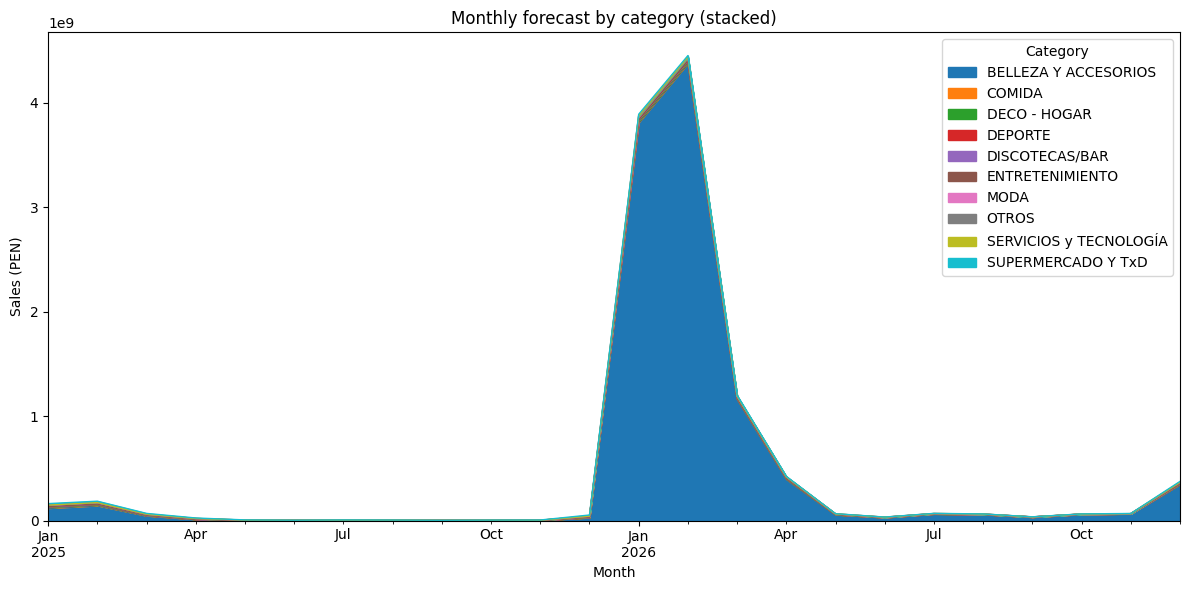

In [ ]:
# @title Modelo Ventas por Cat BDA (Prophet)
# @title Modelo Ventas BDA por Categoría (Daily, log-scale) — mismo set de regresores
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from prophet import Prophet
from datetime import date, timedelta

# Ensure Prophet uses Pystan backend
os.environ['PROPHET_BACKEND'] = 'PYSTAN'

# =========================
# ======= CONFIG ==========
# =========================
INPUT_FILE    = "Ventas Reales hasta Agosto 31 2025.xlsx"
WEATHER_FILE  = "weather_daily.xlsx"  # optional; if missing, neutral weather is used
DATE_COL      = "Fecha"
AMOUNT_COL    = "Monto Soles"
CATEGORY_COL  = "Jerarquia"           # <-- change if your file uses e.g. "Categoría" or "Rubro"

TARGET_CATEGORIES = [
    "SUPERMERCADO Y TxD",
    "DISCOTECAS/BAR",
    "COMIDA",
    "BELLEZA Y ACCESORIOS",
    "DEPORTE",
    "MODA",
    "DECO - HOGAR",
    "SERVICIOS y TECNOLOGÍA",
    "OTROS",
    "ENTRETENIMIENTO",
]

# Windows
train_start = pd.Timestamp("2022-01-01")
train_end   = pd.Timestamp("2024-12-31") #Era 2025-07-31
test_start  = pd.Timestamp("2025-01-01")
test_end    = pd.Timestamp("2025-07-31") #Era 2025-08-01 (Agosto esta raro)
fcst_end    = pd.Timestamp("2026-12-31")

# Prophet hyperparams (kept from your base spec)
PROPHET_KW = dict(
    holidays_prior_scale=30,
    yearly_seasonality=20,
    weekly_seasonality=6,
    daily_seasonality=False,
    seasonality_prior_scale=14.0,
    changepoint_prior_scale=0.001,
    changepoint_range=0.8,
    n_changepoints=25,
    interval_width=0.95,
    seasonality_mode="additive",
)

# Regressor priors
REG_PRIORS = {
    "is_payday": 10,
    "is_vacation": 25,
    "is_long_weekend": 12,
    "is_mothers_day": 10,
    "is_fathers_day": 10,
    "is_black_friday": 16,
    "is_cyber_monday": 16,
    "tmax_c": 5,
    "rain_mm": 6,
    "is_hot_day": 8,
}

# =========================
# ======= LOAD DATA =======
# =========================
df_raw = pd.read_excel(INPUT_FILE)
# Basic column normalization
if DATE_COL not in df_raw.columns or AMOUNT_COL not in df_raw.columns or CATEGORY_COL not in df_raw.columns:
    raise ValueError(
        f"Columns not found. Expected '{DATE_COL}', '{AMOUNT_COL}', '{CATEGORY_COL}'. "
        f"Found: {list(df_raw.columns)}"
    )

df_raw[DATE_COL]   = pd.to_datetime(df_raw[DATE_COL]).dt.floor("D")
df_raw[AMOUNT_COL] = pd.to_numeric(df_raw[AMOUNT_COL], errors="coerce").fillna(0.0)
df_raw[CATEGORY_COL] = df_raw[CATEGORY_COL].astype(str).str.strip()

# Map any unexpected category to "OTROS" so everything lands in the 10 buckets
df_raw["Category"] = np.where(df_raw[CATEGORY_COL].isin(TARGET_CATEGORIES),
                              df_raw[CATEGORY_COL],
                              "OTROS")

# Aggregate DAILY x CATEGORY
df_daily_cat = (
    df_raw.groupby([DATE_COL, "Category"], as_index=False)[AMOUNT_COL]
          .sum()
          .rename(columns={DATE_COL: "ds", AMOUNT_COL: "y"})
          .sort_values(["Category", "ds"])
)

# Make continuous date index per category (fill missing days with 0)
all_days = pd.date_range(df_daily_cat["ds"].min(), max(fcst_end, df_daily_cat["ds"].max()), freq="D")
cats = sorted(df_daily_cat["Category"].unique())
full_idx = pd.MultiIndex.from_product([all_days, cats], names=["ds","Category"])
df_daily_cat = (
    df_daily_cat.set_index(["ds","Category"])
                .reindex(full_idx, fill_value=0.0)
                .reset_index()
)

# Guard against duplicates
df_daily_cat = (df_daily_cat.groupby(["ds","Category"], as_index=False)["y"].sum()
                          .sort_values(["Category","ds"])
                          .reset_index(drop=True))

# Global trims to window
data_min = min(train_start, df_daily_cat["ds"].min())
data_max = max(fcst_end, df_daily_cat["ds"].max())
df_daily_cat = df_daily_cat[(df_daily_cat["ds"] >= data_min) & (df_daily_cat["ds"] <= data_max)].copy()

# =========================
# === CALENDAR FEATURES ===
# =========================
years = list(range(train_start.year, fcst_end.year + 1))

def nth_weekday(y, m, weekday, n):  # Mon=0..Sun=6
    d = date(y, m, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return pd.Timestamp(first) + pd.Timedelta(weeks=n-1)

def mothers_day_pe(y):  # 2nd Sunday of May
    return nth_weekday(y, 5, 6, 2)
def fathers_day_pe(y):  # 3rd Sunday of June
    return nth_weekday(y, 6, 6, 3)
def black_friday(y):    # 4th Friday of Nov
    return nth_weekday(y, 11, 4, 4)
def cyber_monday(y):
    return black_friday(y) + pd.Timedelta(days=3)

# Build once (date-level), then merge to each category
fe = pd.DataFrame({"ds": all_days})
fe["dow"] = fe["ds"].dt.weekday
fe["day"] = fe["ds"].dt.day

# Paydays
fe["is_payday"] = ((fe["day"] == 15) | (fe["ds"] == fe["ds"] + pd.offsets.MonthEnd(0))).astype(int)

# Vacation windows (Dec 15 → Mar 15) + explicit BDA windows (as in your base code)
fe["is_vacation"] = 0
explicit_windows = [
    ("2025-01-01","2025-03-15"),
    ("2025-12-15","2026-03-10"),
]
for start, end in explicit_windows:
    mask = (fe["ds"] >= pd.to_datetime(start)) & (fe["ds"] <= pd.to_datetime(end))
    fe.loc[mask, "is_vacation"] = 1
for y in years:
    start = pd.Timestamp(year=y-1, month=12, day=15)
    end   = pd.Timestamp(year=y,   month=3,  day=15)
    mask = (fe["ds"] >= start) & (fe["ds"] <= end)
    fe.loc[mask, "is_vacation"] = 1

# Long weekends (Peru official holidays)
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"]).dt.normalize()
fe["is_long_weekend"] = 0
holi = set(peru_holidays["ds"].tolist())
dsn = fe["ds"].dt.normalize()
fri_holi = dsn.isin(holi) & (fe["dow"] == 4)
mon_holi = dsn.isin(holi) & (fe["dow"] == 0)
win_days = set()
for d in dsn[fri_holi]:  # Fri..Mon
    for k in [0,1,2,3]:
        win_days.add(d + pd.Timedelta(days=k))
for d in dsn[mon_holi]:  # Sat..Tue
    for k in [-2,-1,0,1]:
        win_days.add(d + pd.Timedelta(days=k))
fe.loc[dsn.isin(win_days), "is_long_weekend"] = 1

# Mother's/Father's Day; Black Friday/Cyber Monday
fe["is_mothers_day"] = 0
fe["is_fathers_day"] = 0
fe["is_black_friday"] = 0
fe["is_cyber_monday"] = 0
md = {y: mothers_day_pe(y) for y in years}
fd = {y: fathers_day_pe(y) for y in years}
bf = {y: black_friday(y) for y in years}
cm = {y: cyber_monday(y) for y in years}
fe.loc[fe["ds"].isin(list(md.values())), "is_mothers_day"] = 1
fe.loc[fe["ds"].isin(list(fd.values())), "is_fathers_day"] = 1
fe.loc[fe["ds"].isin(list(bf.values())), "is_black_friday"] = 1
fe.loc[fe["ds"].isin(list(cm.values())), "is_cyber_monday"] = 1

# =========================
# ===== WEATHER (opt) =====
# =========================
fe["tmax_c"] = np.nan
fe["rain_mm"] = np.nan
fe["is_hot_day"] = 0
try:
    wdf = pd.read_excel(WEATHER_FILE)
    wdf["ds"] = pd.to_datetime(wdf["ds"])
    wdf = wdf[["ds","tmax_c","rain_mm"]].copy()
    wdf["tmax_c"] = pd.to_numeric(wdf["tmax_c"], errors="coerce")
    wdf["rain_mm"] = pd.to_numeric(wdf["rain_mm"], errors="coerce").fillna(0.0)
    # 90th percentile monthly hot flag
    wdf["year"] = wdf["ds"].dt.year
    wdf["month"] = wdf["ds"].dt.month
    thr = wdf.groupby(["year","month"])["tmax_c"].transform(
        lambda s: s.quantile(0.90) if s.notna().any() else np.nan
    )
    wdf["is_hot_day"] = (wdf["tmax_c"] >= thr).astype(int)
    wdf = wdf[["ds","tmax_c","rain_mm","is_hot_day"]]
    fe = fe.merge(wdf, on="ds", how="left", suffixes=("","_w"))
    for c in ["tmax_c","rain_mm","is_hot_day"]:
        fe[c] = fe[f"{c}_w"].combine_first(fe[c])
        if f"{c}_w" in fe.columns: fe.drop(columns=[f"{c}_w"], inplace=True)
except FileNotFoundError:
    pass

# Minimal imputation
if fe["tmax_c"].isna().all():
    fe["tmax_c"] = 0.0
else:
    fe["tmax_c"] = fe["tmax_c"].fillna(fe["tmax_c"].median())
if fe["rain_mm"].isna().all():
    fe["rain_mm"] = 0.0
else:
    fe["rain_mm"] = fe["rain_mm"].fillna(0.0)
fe["is_hot_day"] = fe["is_hot_day"].fillna(0).astype(int)

# Final regressor set
REG_COLS = [
    "is_payday","is_vacation","is_long_weekend",
    "is_mothers_day","is_fathers_day","is_black_friday","is_cyber_monday",
    "tmax_c","rain_mm","is_hot_day"
]

# =========================
# ===== HOLIDAYS TABLE ====
# =========================
# We’ll keep your earlier holiday table (remove Dec 8; add custom pulses)
peru_holidays_full = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays_full["ds"] = pd.to_datetime(peru_holidays_full["ds"])
peru_holidays_full = peru_holidays_full[
    ~((peru_holidays_full["ds"].dt.month == 12) & (peru_holidays_full["ds"].dt.day == 8))
]

def nth_weekday_h(y, m, weekday, n):
    d = date(y, m, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return pd.Timestamp(first) + pd.Timedelta(weeks=n-1)

rows = []
for y in years:
    md_sun = nth_weekday_h(y, 5, 6, 2)
    rows += [
        {"holiday":"MothersDay_Sat","ds": pd.Timestamp(md_sun) - pd.Timedelta(days=1),
         "lower_window":0,"upper_window":0,"prior_scale":65},
        {"holiday":"MothersDay_Sun","ds": pd.Timestamp(md_sun),
         "lower_window":0,"upper_window":0,"prior_scale":25},
    ]
    rows.append(
        {"holiday":"Gratificacion","ds": pd.Timestamp(f"{y}-06-14"),
         "lower_window":0,"upper_window":0,"prior_scale":30}
    )

custom = pd.DataFrame(rows)
dec8_boost = pd.DataFrame({
    "holiday": "Dec8_Boost",
    "ds": [pd.Timestamp(f"{y}-12-08") for y in years],
    "lower_window": 0,
    "upper_window": 0,
    "prior_scale": 110
})
all_holidays = (
    pd.concat([peru_holidays_full, custom, dec8_boost], ignore_index=True)
      .drop_duplicates(subset=["holiday","ds"])
      .sort_values(["ds","holiday"])
      .reset_index(drop=True)
)

# =========================
# === TRAIN & FORECAST ====
# =========================
# Prepare a future dataframe (same for all categories)
periods_needed = (fcst_end - train_end).days
future_dates = pd.DataFrame({"ds": pd.date_range(train_start, fcst_end, freq="D")})
future_reg = fe.copy()  # already has full horizon features
assert future_dates["ds"].min() >= fe["ds"].min() and future_dates["ds"].max() <= fe["ds"].max()

# Collect outputs
fcst_list  = []
metric_rows = []

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def mape_pct(a, b, eps=1e-8):
    mask = np.abs(a) > eps
    return float(np.mean(np.abs((a[mask]-b[mask]) / a[mask]))*100) if mask.sum() else np.nan

for cat in TARGET_CATEGORIES:
    df_cat = df_daily_cat[df_daily_cat["Category"] == cat].copy()
    # Join regressors
    df_cat = df_cat.merge(fe[["ds"] + REG_COLS], on="ds", how="left")
    # Log transform
    df_cat["y_log"] = np.log1p(df_cat["y"])
    # Train set
    train_fit = (df_cat[(df_cat["ds"] >= train_start) & (df_cat["ds"] <= train_end)]
                 [["ds","y_log"] + REG_COLS]
                 .rename(columns={"y_log":"y"})
                 .copy())
    # Model
    m = Prophet(holidays=all_holidays, **PROPHET_KW)
    for r in REG_COLS:
        m.add_regressor(r, prior_scale=REG_PRIORS.get(r, 10))
    # Fit
    m.fit(train_fit)

    # Build future (history + forecast) with regressors
    fut = future_reg[["ds"] + REG_COLS].copy()
    # Predict
    fcst = m.predict(fut)
    # Back-transform
    fcst["yhat"]       = np.expm1(fcst["yhat"])
    fcst["yhat_lower"] = np.expm1(fcst["yhat_lower"])
    fcst["yhat_upper"] = np.expm1(fcst["yhat_upper"])
    fcst["Category"]   = cat

    # Evaluate on test (Aug-2025)
    test_merge = (fcst[(fcst["ds"] >= test_start) & (fcst["ds"] <= test_end)]
                  [["ds","yhat"]]
                  .merge(df_cat[(df_cat["ds"] >= test_start) & (df_cat["ds"] <= test_end)][["ds","y"]],
                         on="ds", how="inner"))
    if len(test_merge):
        _mae  = mae(test_merge["y"].values,   test_merge["yhat"].values)
        _rmse = rmse(test_merge["y"].values,  test_merge["yhat"].values)
        _mape = mape_pct(test_merge["y"].values, test_merge["yhat"].values)
        _wape = float(np.abs(test_merge["y"] - test_merge["yhat"]).sum() / max(test_merge["y"].sum(), 1e-8) * 100.0)
    else:
        _mae = _rmse = _mape = _wape = np.nan

    metric_rows.append({
        "Category": cat, "MAE": _mae, "RMSE": _rmse, "MAPE_%": _mape, "WAPE_%": _wape
    })

    # Keep full horizon (from 2025-01-01 to fcst_end for export/plots if preferred)
    fcst_list.append(fcst)

# Combine forecasts
fcst_all = pd.concat(fcst_list, ignore_index=True)
metrics_df = pd.DataFrame(metric_rows)

print("\n=== Test metrics per category (Aug-2025) ===")
print(metrics_df.sort_values("WAPE_%"))

# =========================
# ======= EXPORTS =========
# =========================
# Daily export (2025-01-01 → 2026-12-31 slice, but includes training history too if you prefer)
daily_export = fcst_all[(fcst_all["ds"] >= pd.Timestamp("2025-01-01")) & (fcst_all["ds"] <= fcst_end)].copy()
daily_export = daily_export[["ds","Category","yhat","yhat_lower","yhat_upper","trend","holidays","weekly","yearly"]]

# Monthly by category
monthly_export = (
    fcst_all
    .loc[(fcst_all["ds"] >= pd.Timestamp("2025-01-01")) & (fcst_all["ds"] <= fcst_end)]
    .assign(Month=lambda d: d["ds"].values.astype("datetime64[M]"))
    .groupby(["Month","Category"], as_index=False)[["yhat","yhat_lower","yhat_upper"]]
    .sum(min_count=1)
    .sort_values(["Month","Category"])
)

with pd.ExcelWriter("prophet_by_category_2025_2026.xlsx", engine="xlsxwriter") as xlw:
    daily_export.to_excel(xlw, index=False, sheet_name="daily_by_category")
    monthly_export.to_excel(xlw, index=False, sheet_name="monthly_by_category")
    metrics_df.to_excel(xlw, index=False, sheet_name="metrics_Aug2025")

print("\nExported:")
print(" - 'prophet_by_category_2025_2026.xlsx' (daily, monthly, metrics)")

# =========================
# ======= PLOTS (opt) =====
# =========================
# Example: stacked monthly totals by category to eyeball seasonality
try:
    pivot = monthly_export.pivot(index="Month", columns="Category", values="yhat").fillna(0.0)
    pivot.plot(kind="area", figsize=(12,6), linewidth=1)
    plt.title("Monthly forecast by category (stacked)")
    plt.ylabel("Sales (PEN)"); plt.xlabel("Month")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Plot skipped:", e)



DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/g2c2myl6.json



=== Category: SUPERMERCADO Y TxD ===


DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/rpxs7ih_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=90773', 'data', 'file=/tmp/tmps71m1fph/g2c2myl6.json', 'init=/tmp/tmps71m1fph/rpxs7ih_.json', 'output', 'file=/tmp/tmps71m1fph/prophet_modelmhqrzn9s/prophet_model-20251027154453.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:44:53 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:44:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/ixr_2ueq.json



=== Category: DISCOTECAS/BAR ===


DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/lk2lt8wb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=41658', 'data', 'file=/tmp/tmps71m1fph/ixr_2ueq.json', 'init=/tmp/tmps71m1fph/lk2lt8wb.json', 'output', 'file=/tmp/tmps71m1fph/prophet_modelc3tejo7x/prophet_model-20251027154454.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:44:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:44:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/0x3rdh14.json


...

  WAPE Jan–Aug 2025: 33.19%

=== Category: OTROS ===


DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/qx251pm4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=37089', 'data', 'file=/tmp/tmps71m1fph/1ityj_zz.json', 'init=/tmp/tmps71m1fph/qx251pm4.json', 'output', 'file=/tmp/tmps71m1fph/prophet_model6l_082__/prophet_model-20251027154501.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:45:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:45:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/1mql16qx.json



=== Category: ENTRETENIMIENTO ===


DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/nphqq072.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47887', 'data', 'file=/tmp/tmps71m1fph/1mql16qx.json', 'init=/tmp/tmps71m1fph/nphqq072.json', 'output', 'file=/tmp/tmps71m1fph/prophet_modeluq7jg4s3/prophet_model-20251027154502.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:45:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:45:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


  WAPE Jan–Aug 2025: 242.34%
Saved 'bda_monthly_forecast_by_category.xlsx'.


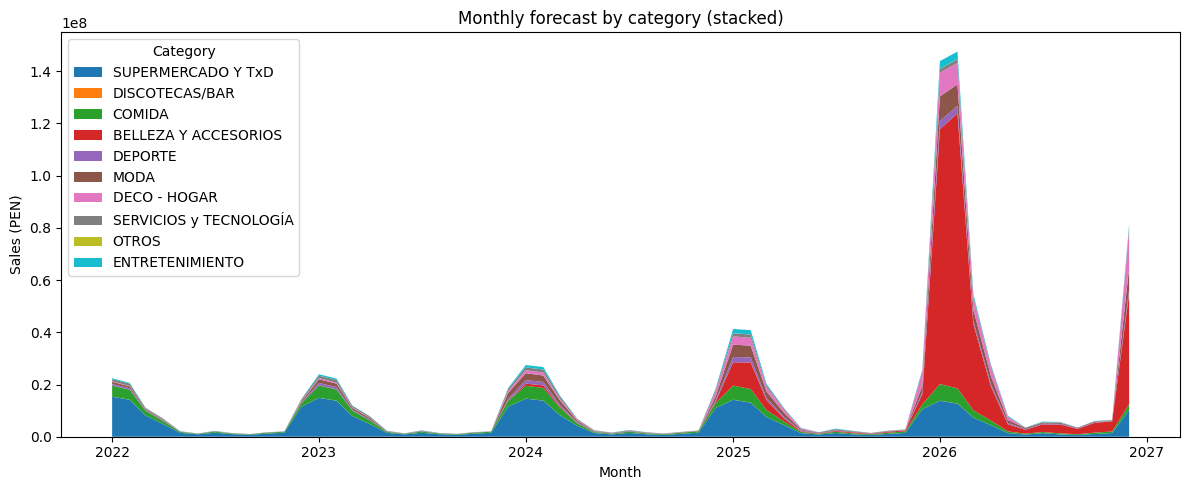

Saved 'bda_daily_forecast_by_category.xlsx'.


In [ ]:
#@title Modelo Ventas por Cat BDA (Prophet)v2 (Ignorar)
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from prophet import Prophet
from datetime import date, timedelta

# Ensure Prophet uses Pystan backend
os.environ['PROPHET_BACKEND'] = 'PYSTAN'

# =========================
# ====== CONFIG ===========
# =========================
DATA_FILE = "Ventas Reales hasta Agosto 31 2025.xlsx"

# Canonical category list (case-insensitive matching)
CATEGORIES = [
    "SUPERMERCADO Y TxD",
    "DISCOTECAS/BAR",
    "COMIDA",
    "BELLEZA Y ACCESORIOS",
    "DEPORTE",
    "MODA",
    "DECO - HOGAR",
    "SERVICIOS y TECNOLOGÍA",
    "OTROS",
    "ENTRETENIMIENTO",
]

# Categories to DAMP holiday spikes (e.g., Belleza)
LOW_HOLIDAY_CATS = {
    "BELLEZA Y ACCESORIOS",
    # add more here if needed, e.g. "MODA"
}
# Only damp these spike-y events (set to None to dampen ALL holiday rows)
LOW_EVENTS = {"XmasRamp", "Gratificacion_Dec", "Dec8_Boost", "NewYearRamp"}

# Windows
train_start = pd.Timestamp("2022-01-01")
train_end   = pd.Timestamp("2025-07-31")   # use real months you trust
test_start  = pd.Timestamp("2025-08-01")
test_end    = pd.Timestamp("2025-08-31")   # optional if you still want a test print
fcst_end    = pd.Timestamp("2026-12-31")

# =========================
# ====== LOAD DATA ========
# =========================
df_raw = pd.read_excel(DATA_FILE)
# Detect columns
def find_col(cands):
    for c in cands:
        if c in df_raw.columns: return c
    return None

date_col = find_col(["Fecha","FECHA","date","Date"])
amt_col  = find_col(["Monto Soles","MONTO SOLES","Monto","Sales","Amount"])
cat_col  = find_col(["Jerarquia","Categoría","CATEGORIA","CATEGORÍA","Categoria (Agrupada)","Category"])

if not date_col or not amt_col or not cat_col:
    raise ValueError(f"Missing columns. Found: {df_raw.columns.tolist()} — need Fecha, Monto, Categoria.")

df_raw = df_raw[[date_col, amt_col, cat_col]].copy()
df_raw.columns = ["ds", "y", "cat"]

df_raw["ds"] = pd.to_datetime(df_raw["ds"]).dt.floor("D")
df_raw["y"]  = pd.to_numeric(df_raw["y"], errors="coerce").fillna(0.0)

# Normalize categories to match canonical labels (basic case-insensitive cleaning)
def norm_cat(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

df_raw["cat"] = df_raw["cat"].map(norm_cat)

# Try to align to canonical set (case-insensitive)
canon_upper = {c.upper(): c for c in CATEGORIES}
df_raw["cat_upper"] = df_raw["cat"].str.upper()
df_raw["cat"] = df_raw["cat_upper"].map(canon_upper).fillna(df_raw["cat"])
df_raw.drop(columns=["cat_upper"], inplace=True)

# Restrict to categories we care about
df_raw = df_raw[df_raw["cat"].isin(CATEGORIES)].copy()

# =========================
# === HOLIDAYS (BASE) =====
# =========================
years      = list(range(train_start.year, fcst_end.year + 1))
years_span = list(range(train_start.year, fcst_end.year + 2))   # for Dec Y-1 → Mar Y windows

def nth_weekday(y, m, weekday, n):  # Mon=0..Sun=6
    d = date(y, m, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return pd.Timestamp(first + timedelta(weeks=n-1))

def mothers_day_pe(y):  # 2nd Sunday of May
    return nth_weekday(y, 5, 6, 2)
def fathers_day_pe(y):  # 3rd Sunday of June
    return nth_weekday(y, 6, 6, 3)
def black_friday(y):    # 4th Friday of Nov
    return nth_weekday(y, 11, 4, 4)
def cyber_monday(y):
    return black_friday(y) + pd.Timedelta(days=3)

# Peru official (for Prophet holiday table)
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"])

# Remove Dec 8 so we use a single tall pulse below
peru_holidays = peru_holidays[~((peru_holidays["ds"].dt.month == 12) & (peru_holidays["ds"].dt.day == 8))]

# Custom pulses (incl. stronger December)
rows = []
for y in years:
    md_sun = mothers_day_pe(y)
    rows += [
        {"holiday":"MothersDay_Sat","ds": md_sun - pd.Timedelta(days=1),
         "lower_window":0,"upper_window":0,"prior_scale":65},
        {"holiday":"MothersDay_Sun","ds": md_sun,
         "lower_window":0,"upper_window":0,"prior_scale":25},
        {"holiday":"Gratificacion_Jun","ds": pd.Timestamp(f"{y}-06-14"),
         "lower_window":0,"upper_window":0,"prior_scale":30},
        {"holiday":"Gratificacion_Dec","ds": pd.Timestamp(f"{y}-12-15"),
         "lower_window":0,"upper_window":0,"prior_scale":50},
        {"holiday":"XmasRamp","ds": pd.Timestamp(f"{y}-12-24"),
         "lower_window":-10,"upper_window":0,"prior_scale":55},
        {"holiday":"NewYearRamp","ds": pd.Timestamp(f"{y}-12-31"),
         "lower_window":-3,"upper_window":1,"prior_scale":25},
    ]
dec8_boost = pd.DataFrame({
    "holiday": "Dec8_Boost",
    "ds": [pd.Timestamp(f"{y}-12-08") for y in years],
    "lower_window": 0, "upper_window": 0, "prior_scale": 110
})
custom = pd.DataFrame(rows)

all_holidays_base = (
    pd.concat([peru_holidays, custom, dec8_boost], ignore_index=True)
      .drop_duplicates(subset=["holiday","ds"])
      .sort_values(["ds","holiday"])
      .reset_index(drop=True)
)

# =========================
# === LONG WEEKEND BASE ===
# =========================
peru_h_days = pd.DataFrame(
    [(d, n) for yy in years for d, n in holidays.Peru(years=yy).items()],
    columns=["ds", "holiday"]
)
peru_h_days["ds"] = pd.to_datetime(peru_h_days["ds"]).dt.normalize()
PERU_H_SET = set(peru_h_days["ds"].tolist())

# =========================
# === WEATHER (OPTIONAL) ==
# =========================
weather_loaded = False
try:
    wdf = pd.read_excel("weather_daily.xlsx")  # expects ds, tmax_c, rain_mm
    wdf["ds"] = pd.to_datetime(wdf["ds"]).dt.floor("D")
    wdf["tmax_c"] = pd.to_numeric(wdf["tmax_c"], errors="coerce")
    wdf["rain_mm"] = pd.to_numeric(wdf["rain_mm"], errors="coerce").fillna(0.0)
    wdf = wdf[["ds","tmax_c","rain_mm"]].dropna(subset=["ds"])
    # Monthly 90th threshold for hot-day
    tmp = wdf.copy()
    tmp["year"] = tmp["ds"].dt.year
    tmp["month"] = tmp["ds"].dt.month
    thr = tmp.groupby(["year","month"])["tmax_c"].transform(lambda s: s.quantile(0.90) if s.notna().any() else np.nan)
    tmp["is_hot_day"] = (tmp["tmax_c"] >= thr).astype(int)
    weather = tmp[["ds","tmax_c","rain_mm","is_hot_day"]].copy()
    weather_loaded = True
except FileNotFoundError:
    weather = pd.DataFrame(columns=["ds","tmax_c","rain_mm","is_hot_day"])

# =========================
# == PER-CATEGORY UTILS ===
# =========================
def holidays_for_category(base_holidays: pd.DataFrame,
                          category: str,
                          low_scale: float = 2.0,
                          cap_mode: str = "min",
                          only_events: set | None = LOW_EVENTS,
                          default_if_missing: float = 10.0) -> pd.DataFrame:
    h = base_holidays.copy()
    if "prior_scale" not in h.columns:
        h["prior_scale"] = default_if_missing
    h["prior_scale"] = pd.to_numeric(h["prior_scale"], errors="coerce").fillna(default_if_missing)

    if category.upper() not in {c.upper() for c in LOW_HOLIDAY_CATS}:
        return h

    mask = pd.Series(True, index=h.index)
    if only_events:
        mask &= h["holiday"].isin(only_events)

    if cap_mode == "set":
        h.loc[mask, "prior_scale"] = float(low_scale)
    elif cap_mode == "min":
        h.loc[mask, "prior_scale"] = np.minimum(h.loc[mask, "prior_scale"].values, float(low_scale))
    elif cap_mode == "multiply":
        h.loc[mask, "prior_scale"] = h.loc[mask, "prior_scale"].values * float(low_scale)
    else:
        raise ValueError("cap_mode must be one of {'set','min','multiply'}")
    return h

def build_features(dates: pd.Series) -> pd.DataFrame:
    out = pd.DataFrame({"ds": pd.to_datetime(dates).sort_values().unique()})
    out["dow"] = out["ds"].dt.weekday
    out["day"] = out["ds"].dt.day
    # Paydays
    out["is_payday"] = ((out["day"] == 15) | (out["ds"] == out["ds"] + pd.offsets.MonthEnd(0))).astype(int)
    # Vacation windows Dec1 → Mar15 (cover one extra year for Dec-2026)
    out["is_vacation"] = 0
    for y in years_span:
        start = pd.Timestamp(year=y-1, month=12, day=1)
        end   = pd.Timestamp(year=y,   month=3,  day=15)
        mask = (out["ds"] >= start) & (out["ds"] <= end)
        out.loc[mask, "is_vacation"] = 1
    # Long weekends
    out["is_long_weekend"] = 0
    dsn = out["ds"].dt.normalize()
    fri_holi = dsn.isin(PERU_H_SET) & (out["dow"] == 4)
    mon_holi = dsn.isin(PERU_H_SET) & (out["dow"] == 0)
    win_days = set()
    for d in dsn[fri_holi]:
        for k in [0,1,2,3]: win_days.add(d + pd.Timedelta(days=k))
    for d in dsn[mon_holi]:
        for k in [-2,-1,0,1]: win_days.add(d + pd.Timedelta(days=k))
    out.loc[dsn.isin(win_days), "is_long_weekend"] = 1
    # Mother/Father + BF/CM
    out["is_mothers_day"] = 0; out["is_fathers_day"] = 0
    out["is_black_friday"] = 0; out["is_cyber_monday"] = 0
    md = {y: mothers_day_pe(y) for y in years}
    fd = {y: fathers_day_pe(y) for y in years}
    bf = {y: black_friday(y) for y in years}
    cm = {y: cyber_monday(y) for y in years}
    out.loc[out["ds"].isin(list(md.values())), "is_mothers_day"] = 1
    out.loc[out["ds"].isin(list(fd.values())), "is_fathers_day"] = 1
    out.loc[out["ds"].isin(list(bf.values())), "is_black_friday"] = 1
    out.loc[out["ds"].isin(list(cm.values())), "is_cyber_monday"] = 1
    # December flag
    out["is_december"] = (out["ds"].dt.month == 12).astype(int)
    # Weather merge (or neutral)
    out = out.merge(weather, on="ds", how="left")
    if weather_loaded:
        out["tmax_c"] = out["tmax_c"].fillna(out["tmax_c"].median())
        out["rain_mm"] = out["rain_mm"].fillna(0.0)
        out["is_hot_day"] = out["is_hot_day"].fillna(0).astype(int)
    else:
        out["tmax_c"] = 0.0
        out["rain_mm"] = 0.0
        out["is_hot_day"] = 0
    return out.drop(columns=["dow","day"])

reg_cols = [
    "is_payday","is_vacation","is_long_weekend",
    "is_mothers_day","is_fathers_day","is_black_friday","is_cyber_monday",
    "is_december","tmax_c","rain_mm","is_hot_day"
]
prior_scales = {
    "is_payday": 10, "is_vacation": 25, "is_long_weekend": 12,
    "is_mothers_day": 10, "is_fathers_day": 10,
    "is_black_friday": 16, "is_cyber_monday": 16,
    "is_december": 8, "tmax_c": 5, "rain_mm": 6, "is_hot_day": 8,
}

# =========================
# == PER-CATEGORY LOOP ====
# =========================
all_monthly = []  # to collect monthly forecasts per category
all_daily   = []  # optional: collect daily

for cat in CATEGORIES:
    print(f"\n=== Category: {cat} ===")

    # Slice & aggregate to daily
    dfc = df_raw[df_raw["cat"] == cat][["ds","y"]].copy()
    if dfc.empty:
        print("  [WARN] No data for this category; skipping.")
        continue

    # Continuous daily index
    data_min = min(train_start, dfc["ds"].min())
    data_max = max(fcst_end, dfc["ds"].max())
    full_idx = pd.date_range(data_min, data_max, freq="D")

    dfc = (dfc.set_index("ds").groupby(level=0)["y"].sum()
                .reindex(full_idx).fillna(0.0).rename_axis("ds").reset_index())

    # Train/test splits
    train_df = dfc[(dfc["ds"] >= train_start) & (dfc["ds"] <= train_end)].copy()
    test_df  = dfc[(dfc["ds"] >= test_start)  & (dfc["ds"] <= test_end)].copy()

    # Log target
    dfc["y_log"] = np.log1p(dfc["y"])

    # Features (history & future share same function)
    feats = build_features(dfc["ds"])
    dfc   = dfc.merge(feats, on="ds", how="left")

    # Holidays for THIS category (dampen if configured)
    all_holidays_cat = holidays_for_category(
        base_holidays=all_holidays_base,
        category=cat,
        low_scale=5.0,           # << your requested damp level
        cap_mode="min",          # keep lower if already low
        only_events=LOW_EVENTS   # or None for all holiday rows
    )

    # Prophet model
    m = Prophet(
        holidays=all_holidays_cat,
        holidays_prior_scale=30,     # per-row prior_scale overrides this
        yearly_seasonality=20,
        weekly_seasonality=6,
        daily_seasonality=False,
        seasonality_prior_scale=14.0,
        changepoint_prior_scale=0.001,
        changepoint_range=0.8,
        n_changepoints=25,
        interval_width=0.95,
        seasonality_mode="additive",
    )
    for r in reg_cols:
        m.add_regressor(r, prior_scale=prior_scales.get(r,10))

    train_fit = (dfc[(dfc["ds"] >= train_start) & (dfc["ds"] <= train_end)]
                    [["ds","y_log"] + reg_cols]
                    .rename(columns={"y_log":"y"})
                    .copy())
    m.fit(train_fit)

    # Forecast
    periods_needed = (fcst_end - train_end).days
    future = m.make_future_dataframe(periods=periods_needed, freq="D", include_history=True)

    # Build future features and attach
    fut_feats = build_features(future["ds"])
    future = future.merge(fut_feats, on="ds", how="left")

    fcst = m.predict(future)
    fcst["yhat"]       = np.expm1(fcst["yhat"])
    fcst["yhat_lower"] = np.expm1(fcst["yhat_lower"])
    fcst["yhat_upper"] = np.expm1(fcst["yhat_upper"])
    fcst["cat"] = cat

    # Collect daily & monthly
    all_daily.append(fcst[["ds","cat","yhat","yhat_lower","yhat_upper"]].copy())

    monthly = (fcst[["ds","yhat"]]
               .set_index("ds")
               .resample("MS").sum(min_count=1)
               .reset_index())
    monthly["cat"] = cat
    all_monthly.append(monthly)

    # Optional quick metric for Jan–Aug 2025
    if not test_df.empty:
        pred_test = (fcst[(fcst["ds"] >= test_start) & (fcst["ds"] <= test_end)]
                        [["ds","yhat"]]
                        .merge(test_df, on="ds", how="inner"))
        if not pred_test.empty and pred_test["y"].sum() > 0:
            wape = np.abs(pred_test["y"] - pred_test["yhat"]).sum() / pred_test["y"].sum()
            print(f"  WAPE Jan–Aug 2025: {100*wape:.2f}%")

# =========================
# === OUTPUT & PLOTS ======
# =========================
if all_monthly:
    monthly_all = pd.concat(all_monthly, ignore_index=True)
    # Pivot for stacked plot
    piv = monthly_all.pivot_table(index="ds", columns="cat", values="yhat", aggfunc="sum").fillna(0.0)
    # Save monthly by category
    out_monthly = piv.copy().reset_index().rename(columns={"ds":"Month"})
    out_monthly.to_excel("bda_monthly_forecast_by_category.xlsx", index=False)
    print("Saved 'bda_monthly_forecast_by_category.xlsx'.")

    # Stacked area
    plt.figure(figsize=(12,5))
    plt.stackplot(piv.index, [piv[c] for c in CATEGORIES if c in piv.columns], labels=[c for c in CATEGORIES if c in piv.columns])
    plt.legend(loc="upper left", title="Category")
    plt.title("Monthly forecast by category (stacked)")
    plt.xlabel("Month"); plt.ylabel("Sales (PEN)")
    plt.tight_layout(); plt.show()

if all_daily:
    daily_all = pd.concat(all_daily, ignore_index=True)
    # Save per-category daily forecasts (wide)
    daily_wide = (daily_all.pivot_table(index="ds", columns="cat", values="yhat", aggfunc="sum")
                            .reset_index().rename_axis(None, axis=1))
    daily_wide.to_excel("bda_daily_forecast_by_category.xlsx", index=False)
    print("Saved 'bda_daily_forecast_by_category.xlsx'.")


DEBUG:cmdstanpy:input tempfile: /tmp/tmpgqugtg7r/jc3x6m5p.json


Training window: 2022-01-01 → 2024-12-31  (1096 days)
Test window:     2025-01-01  → 2025-07-31   (212 days)


DEBUG:cmdstanpy:input tempfile: /tmp/tmpgqugtg7r/vrzp89ra.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=44958', 'data', 'file=/tmp/tmpgqugtg7r/jc3x6m5p.json', 'init=/tmp/tmpgqugtg7r/vrzp89ra.json', 'output', 'file=/tmp/tmpgqugtg7r/prophet_model15zvjd31/prophet_model-20251024153826.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:38:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:38:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



=== Test metrics (Daily, Jan–Aug 2025) ===
MAE   : 65,604.55
RMSE  : 113,175.41
MAPE% : 15.86


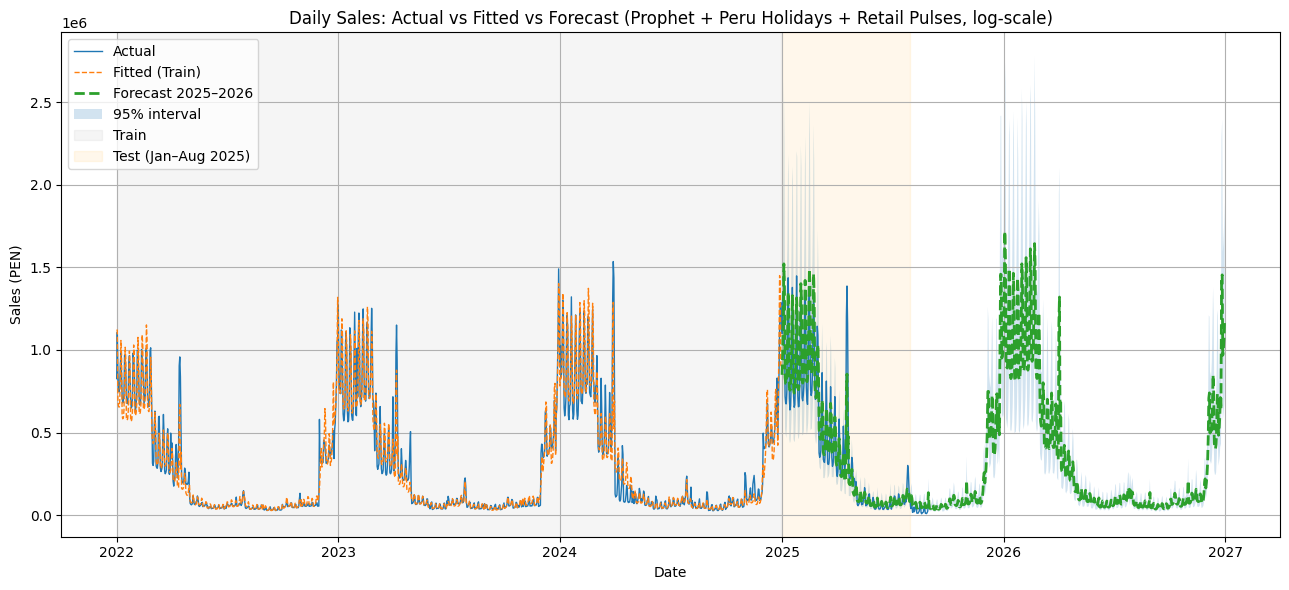

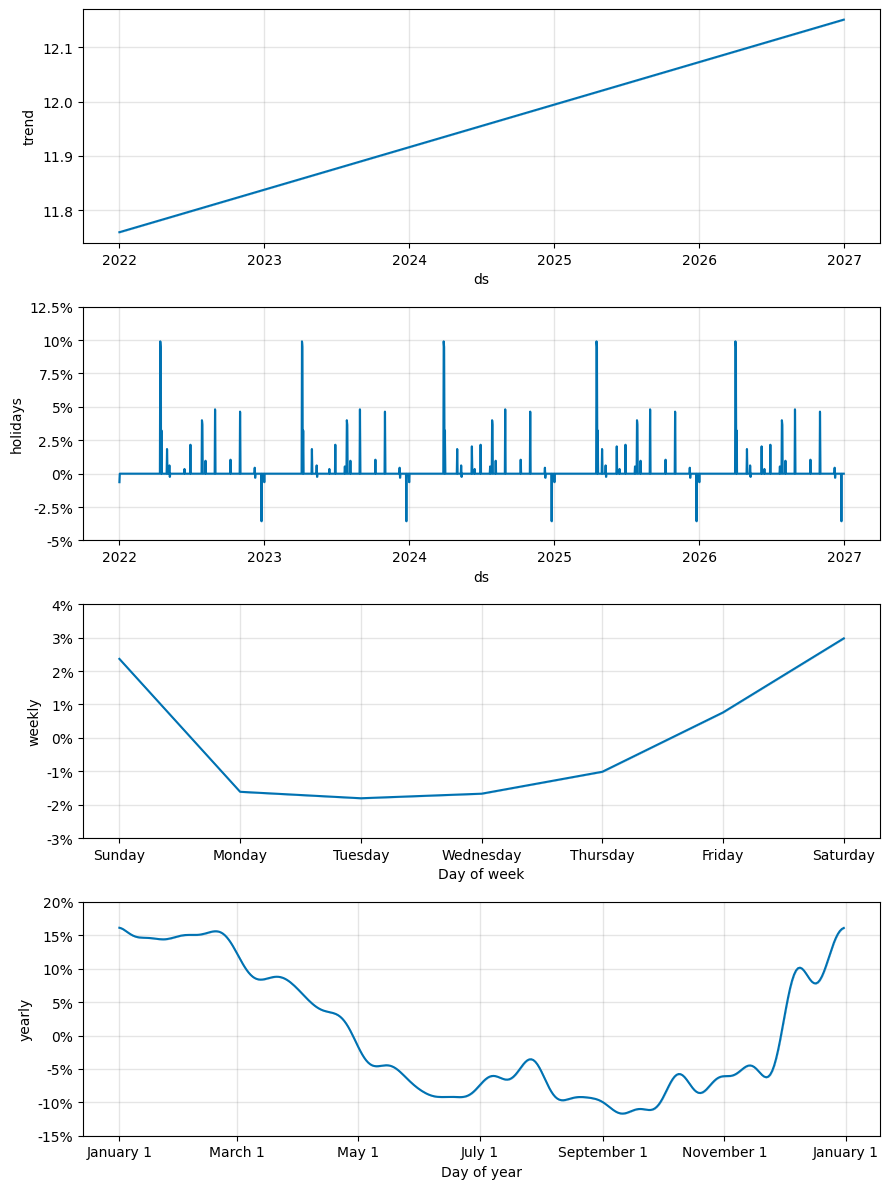

Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.
Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.

Top 25 days by absolute error:
             ds           y          yhat        abs_err       ape
108 2025-04-19  1157120.73  3.525814e+05  804539.298222  0.695294
107 2025-04-18  1387020.98  8.537698e+05  533251.162179  0.384458
106 2025-04-17  1202997.55  7.308032e+05  472194.330205  0.392515
1   2025-01-02  1344394.32  9.820025e+05  362391.857375  0.269558
46  2025-02-16  1082737.48  1.396600e+06  313862.539275  0.289879
58  2025-02-28  1143425.40  8.441348e+05  299290.628839  0.261749
105 2025-04-16   497307.09  2.070506e+05  290256.511362  0.583656
4   2025-01-05  1097776.56  1.377922e+06  280145.053671  0.255193
0   2025-01-01  1099677.54  8.493525e+05  250325.023752  0.227635
3   2025-01-04  1324197.11  1.521055e+06  196857.745908  0.148662
39  2025-02-09  1141576.59  1.321815e+06  180238.688375  0.157886
32  2025-02-02  1131979

In [ ]:
# @title Modelo Ventas BDA (v1 -Prototipo)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from prophet import Prophet
from datetime import date, timedelta

# Ensure Prophet uses Pystan backend
os.environ['PROPHET_BACKEND'] = 'PYSTAN'

# ---------------------------------------------------
# 1) Load & aggregate DAILY (sum per calendar day)
# ---------------------------------------------------
# If your file has an extension, include it (e.g., "...xlsx")
df_raw = pd.read_excel("Ventas Reales hasta Agosto 31 2025.xlsx", usecols="D,H")
df_raw.columns = ["Fecha", "Monto Soles"]

df_raw["Fecha"] = pd.to_datetime(df_raw["Fecha"]).dt.floor("D")
df_raw["Monto Soles"] = pd.to_numeric(df_raw["Monto Soles"], errors="coerce").fillna(0.0)

df_daily = (
    df_raw.groupby("Fecha", as_index=False)["Monto Soles"]
          .sum()
          .rename(columns={"Fecha": "ds", "Monto Soles": "y"})
          .sort_values("ds")
)

# Make series continuous (fill missing days with 0)
full_idx = pd.date_range(df_daily["ds"].min(), df_daily["ds"].max(), freq="D")
df_daily = (
    df_daily.set_index("ds")
            .reindex(full_idx)
            .rename_axis("ds")
            .fillna({"y": 0.0})
            .reset_index()
)

# Hard guard against any accidental duplicate dates
df_daily = (df_daily
            .groupby("ds", as_index=False)["y"].sum()
            .sort_values("ds")
            .reset_index(drop=True))

# ---------------------------------------------------
# 2) Windows
# ---------------------------------------------------
train_start = pd.Timestamp("2022-01-01")
train_end   = pd.Timestamp("2024-12-31")
test_start  = pd.Timestamp("2025-01-01")
test_end    = pd.Timestamp("2025-07-31")
fcst_end    = pd.Timestamp("2026-12-31")

data_min = min(train_start, df_daily["ds"].min())
data_max = max(fcst_end, df_daily["ds"].max())
df_daily = df_daily[(df_daily["ds"] >= data_min) & (df_daily["ds"] <= data_max)].copy()

train_df = df_daily[(df_daily["ds"] >= train_start) & (df_daily["ds"] <= train_end)].copy()
test_df  = df_daily[(df_daily["ds"] >= test_start)  & (df_daily["ds"] <= test_end)].copy()

print(f"Training window: {train_df['ds'].min().date()} → {train_df['ds'].max().date()}  ({len(train_df)} days)")
print(f"Test window:     {test_df['ds'].min().date()}  → {test_df['ds'].max().date()}   ({len(test_df)} days)")

# ---------------------------------------------------
# 3) Log-transform target (multiplicative effects on original scale)
# ---------------------------------------------------
df_log = df_daily.copy()
df_log["y_log"] = np.log1p(df_log["y"])  # robust with zeros

# Build CLEAN train_fit directly from df_log (avoid merges that duplicate columns)
train_fit = df_log[(df_log["ds"] >= train_start) & (df_log["ds"] <= train_end)][["ds","y_log"]] \
                 .rename(columns={"y_log":"y"}) \
                 .copy()

# Assert uniqueness of ds for Prophet; auto-fix if needed
dupes = train_fit["ds"].duplicated().sum()
if dupes:
    print(f"[WARN] Found {dupes} duplicate ds in train_fit; aggregating duplicates.")
    train_fit = train_fit.groupby("ds", as_index=False)["y"].mean()

# ---------------------------------------------------
# 4) Holidays: official Peru + custom retail pulses (taller, not wider)
# ---------------------------------------------------
years = list(range(train_start.year, fcst_end.year + 1))

# Official Peru holidays
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"])

# Remove Dec 8 so effect isn't split
peru_holidays = peru_holidays[
    ~((peru_holidays["ds"].dt.month == 12) & (peru_holidays["ds"].dt.day == 8))
]

# Helpers
def nth_weekday(year, month, weekday, n):  # Mon=0..Sun=6
    d = date(year, month, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return first + timedelta(weeks=n-1)

# Custom events across all years (Mother's Day SAT/SUN, Gratificacion day)
rows = []
for y in years:
    # Mother's Day: 2nd Sunday of May (Peru) — Saturday is the biggest retail day
    md_sun = nth_weekday(y, 5, 6, 2)
    rows += [
        {"holiday":"MothersDay_Sat","ds": pd.Timestamp(md_sun) - pd.Timedelta(days=1),
         "lower_window":0,"upper_window":0,"prior_scale":65},
        {"holiday":"MothersDay_Sun","ds": pd.Timestamp(md_sun),
         "lower_window":0,"upper_window":0,"prior_scale":25},
    ]
    # Gratificacion: June 14 (single-day)
    rows.append(
        {"holiday":"Gratificacion","ds": pd.Timestamp(f"{y}-06-14"),
         "lower_window":0,"upper_window":0,"prior_scale":30}
    )

custom = pd.DataFrame(rows)

# Single tall pulse for Dec 8 (Immaculate Conception)
dec8_boost = pd.DataFrame({
    "holiday": "Dec8_Boost",
    "ds": [pd.Timestamp(f"{y}-12-08") for y in years],
    "lower_window": 0,
    "upper_window": 0,
    "prior_scale": 110  # raise if still short (e.g., 120)
})

# Final holiday table
all_holidays = (
    pd.concat([peru_holidays, custom, dec8_boost], ignore_index=True)
      .drop_duplicates(subset=["holiday","ds"])
      .sort_values(["ds","holiday"])
      .reset_index(drop=True)
)

# ---------------------------------------------------
# 5) Model (additive in log-space → multiplicative on original scale)
# ---------------------------------------------------
m = Prophet(
    holidays=all_holidays,       # per-row prior_scale overrides global
    holidays_prior_scale=30, #was 28
    yearly_seasonality=20, #was 15
    weekly_seasonality=6, #was 6
    daily_seasonality=False,
    seasonality_prior_scale=14.0,
    changepoint_prior_scale=0.001,  # tight trend (stable)
    changepoint_range=0.8,
    n_changepoints=25,
    interval_width=0.95,
    seasonality_mode="additive"
)
"""
# Intra-month cycle on daily data
m.add_seasonality(name="monthly", period=30.5, fourier_order=9)
"""
# Fit on LOG target
m.fit(train_fit)

# ---------------------------------------------------
# 6) Forecast through 2026-12-31 and back-transform
# ---------------------------------------------------
periods_needed = (fcst_end - train_end).days
future = m.make_future_dataframe(periods=periods_needed, freq="D", include_history=True)
forecast = m.predict(future)

# Back-transform to original units
forecast["yhat"]       = np.expm1(forecast["yhat"])
forecast["yhat_lower"] = np.expm1(forecast["yhat_lower"])
forecast["yhat_upper"] = np.expm1(forecast["yhat_upper"])

# ---------------------------------------------------
# 7) Evaluation (Test: 2025-01-01 → 2025-08-31)
# ---------------------------------------------------
pred_test = forecast[(forecast["ds"] >= test_start) & (forecast["ds"] <= test_end)][
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].merge(test_df, on="ds", how="inner")

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def mape_pct(a, b, eps=1e-8):
    mask = np.abs(a) > eps
    return float(np.mean(np.abs((a[mask]-b[mask]) / a[mask]))*100) if mask.sum() else np.nan

test_mae  = mae(pred_test["y"].values,   pred_test["yhat"].values)
test_rmse = rmse(pred_test["y"].values,  pred_test["yhat"].values)
test_mape = mape_pct(pred_test["y"].values, pred_test["yhat"].values)

print("\n=== Test metrics (Daily, Jan–Aug 2025) ===")
print(f"MAE   : {test_mae:,.2f}")
print(f"RMSE  : {test_rmse:,.2f}")
print(f"MAPE% : {test_mape:,.2f}")

# ---------------------------------------------------
# 8) Plots
# ---------------------------------------------------
plt.figure(figsize=(13,6))
plt.plot(df_daily["ds"], df_daily["y"], label="Actual", linewidth=1)

# In-sample fitted (back-transformed)
fitted_hist = forecast[(forecast["ds"] >= train_start) & (forecast["ds"] <= train_end)]
plt.plot(fitted_hist["ds"], fitted_hist["yhat"], label="Fitted (Train)", linestyle="--", linewidth=1)

# Forecast 2025–2026
fcst_horiz = forecast[(forecast["ds"] >= pd.Timestamp("2025-01-01")) & (forecast["ds"] <= fcst_end)]
plt.plot(fcst_horiz["ds"], fcst_horiz["yhat"], label="Forecast 2025–2026", linestyle="--", linewidth=2)
plt.fill_between(fcst_horiz["ds"], fcst_horiz["yhat_upper"], fcst_horiz["yhat_lower"], alpha=0.2, label="95% interval")

# Shade train/test
plt.axvspan(train_start, train_end, color="grey", alpha=0.08, label="Train")
plt.axvspan(test_start,  test_end,  color="orange", alpha=0.08, label="Test (Jan–Aug 2025)")

plt.title("Daily Sales: Actual vs Fitted vs Forecast (Prophet + Peru Holidays + Retail Pulses, log-scale)")
plt.xlabel("Date"); plt.ylabel("Sales (PEN)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Components
m.plot_components(forecast); plt.tight_layout(); plt.show()

# ---------------------------------------------------
# 9) Exports
# ---------------------------------------------------
out = fcst_horiz.copy()
out["deseasonalized"] = out["trend"]  # trend was modeled in log-space
out_cols = ["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "deseasonalized"]
out[out_cols].to_excel("prophet_forecast_2025_2026_daily.xlsx", index=False)
print("Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.")

monthly_2526 = (
    out.set_index("ds")[["yhat","yhat_lower","yhat_upper","trend"]]
      .resample("MS").sum(min_count=1)
      .reset_index()
)
monthly_2526.to_excel("prophet_forecast_2025_2026_monthly_from_daily.xlsx", index=False)
print("Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.")

# ---------------------------------------------------
# 10) Peak diagnostics (optional)
# ---------------------------------------------------
mask = (forecast["ds"] >= "2025-01-01") & (forecast["ds"] <= "2026-12-31")
pred = forecast.loc[mask, ["ds","yhat","yhat_lower","yhat_upper"]].merge(df_daily[["ds","y"]], on="ds", how="left")
pred["err"] = pred["y"] - pred["yhat"]
pred["abs_err"] = pred["err"].abs()
pred["squared_err"] = pred["err"]**2
pred["ape"] = pred["abs_err"] / np.where(pred["y"].abs()>1e-8, pred["y"], np.nan)

top_abs = pred.nlargest(25, "abs_err")[["ds","y","yhat","abs_err","ape"]]
print("\nTop 25 days by absolute error:\n", top_abs)

# Map events
ev_map = (all_holidays.groupby("ds")["holiday"]
                 .apply(lambda s: ",".join(sorted(set(s))))
                 .reset_index()
                 .rename(columns={"holiday":"event"}))
top_with_events = top_abs.merge(ev_map, on="ds", how="left")
print("\nTop 25 with event labels:\n", top_with_events[["ds","event","y","yhat","abs_err","ape"]])

# Check Dec 8 heights by year
for yr in [2022, 2023, 2024, 2025, 2026]:
    row = forecast.loc[forecast["ds"] == pd.Timestamp(f"{yr}-12-08"), ["ds","yhat","holidays","trend"]]
    print(row.to_string(index=False))


DEBUG:cmdstanpy:input tempfile: /tmp/tmpgqugtg7r/w3s7nccr.json


Training window: 2022-01-01 → 2024-12-31  (1096 days)
Test window:     2025-01-01  → 2025-07-31   (212 days)


DEBUG:cmdstanpy:input tempfile: /tmp/tmpgqugtg7r/0h7ml8s3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=13454', 'data', 'file=/tmp/tmpgqugtg7r/w3s7nccr.json', 'init=/tmp/tmpgqugtg7r/0h7ml8s3.json', 'output', 'file=/tmp/tmpgqugtg7r/prophet_modelvwx45wtd/prophet_model-20251024162906.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:29:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:29:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



=== Test metrics (Daily, Jan–Aug 2025) ===
MAE   : 59,503.15
RMSE  : 99,164.15
MAPE% : 15.03
WAPE: 13.73 %


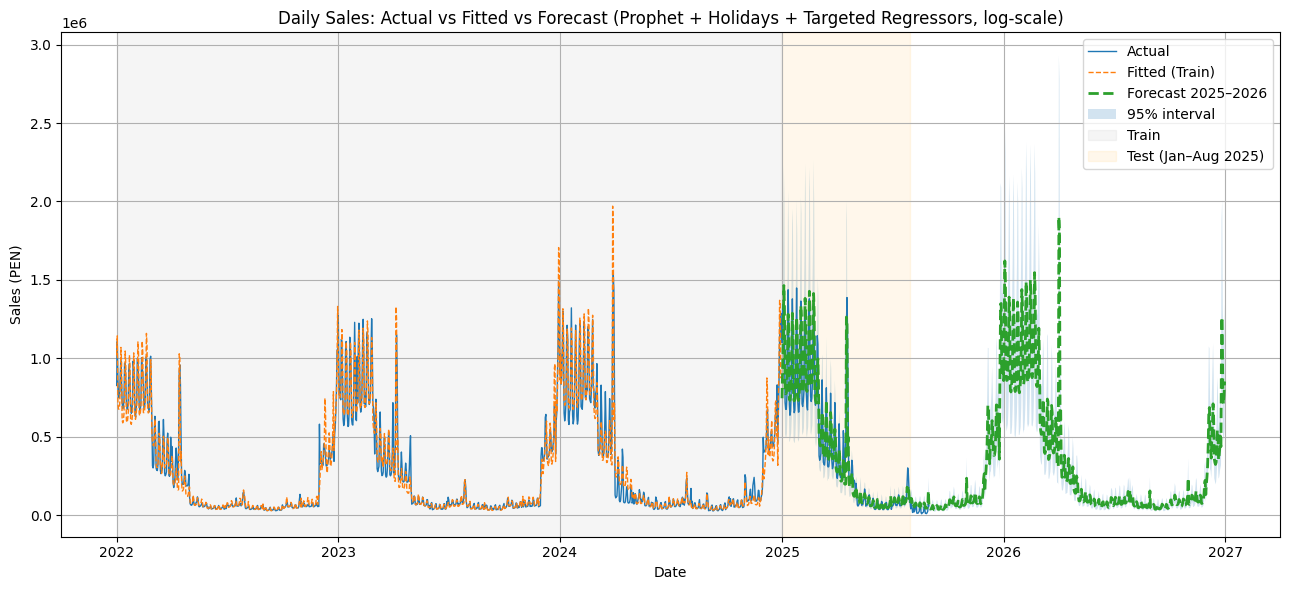

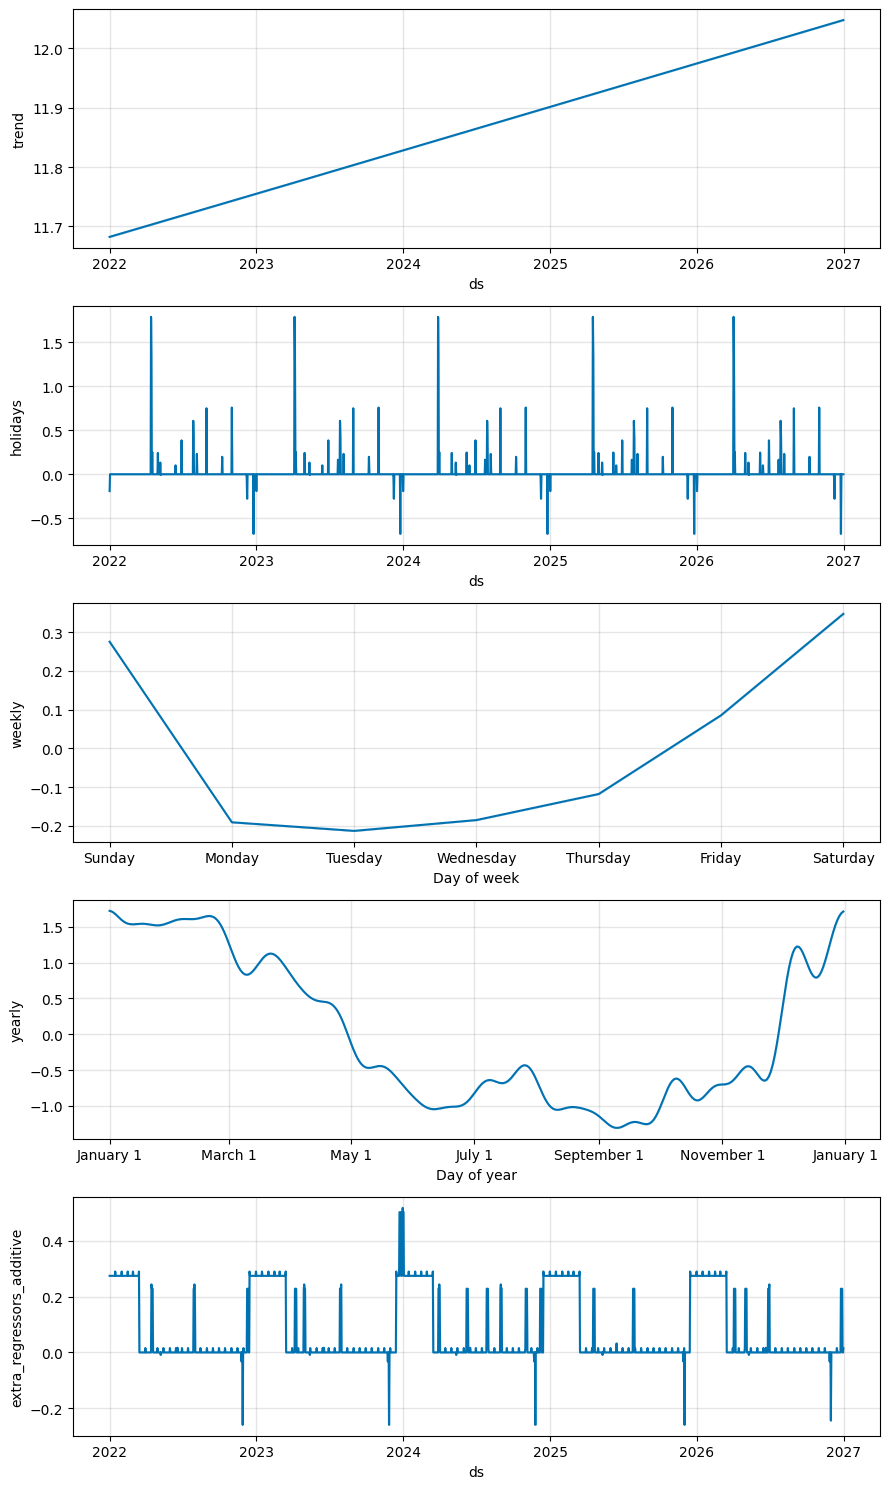

Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.
Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.

Top 25 days by absolute error:
             ds           y          yhat        abs_err       ape
108 2025-04-19  1157120.73  4.186650e+05  738455.762905  0.638184
1   2025-01-02  1344394.32  9.577588e+05  386635.501859  0.287591
0   2025-01-01  1099677.54  7.448804e+05  354797.155852  0.322637
58  2025-02-28  1143425.40  8.375475e+05  305877.900017  0.267510
105 2025-04-16   497307.09  1.978952e+05  299411.882100  0.602066
46  2025-02-16  1082737.48  1.318306e+06  235568.387696  0.217567
4   2025-01-05  1097776.56  1.326242e+06  228465.795350  0.208117
66  2025-03-08   862019.98  6.558572e+05  206162.753762  0.239162
44  2025-02-14  1274533.32  1.073909e+06  200623.870602  0.157410
101 2025-04-12   538652.81  3.474306e+05  191222.176292  0.355001
24  2025-01-25  1448095.92  1.261359e+06  186737.387871  0.128954
9   2025-01-10  1165993

In [ ]:
# @title Modelo Ventas BDA vf -1 (Train hasta dic 2024)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from prophet import Prophet
from datetime import date, timedelta

# Ensure Prophet uses Pystan backend
os.environ['PROPHET_BACKEND'] = 'PYSTAN'

# ---------------------------------------------------
# 1) Load & aggregate DAILY (sum per calendar day)
# ---------------------------------------------------
# If your file has an extension, include it (e.g., "...xlsx")
df_raw = pd.read_excel("Ventas Reales hasta Agosto 31 2025.xlsx", usecols="D,H")
df_raw.columns = ["Fecha", "Monto Soles"]

df_raw["Fecha"] = pd.to_datetime(df_raw["Fecha"]).dt.floor("D")
df_raw["Monto Soles"] = pd.to_numeric(df_raw["Monto Soles"], errors="coerce").fillna(0.0)

df_daily = (
    df_raw.groupby("Fecha", as_index=False)["Monto Soles"]
          .sum()
          .rename(columns={"Fecha": "ds", "Monto Soles": "y"})
          .sort_values("ds")
)

# Make series continuous (fill missing days with 0)
full_idx = pd.date_range(df_daily["ds"].min(), df_daily["ds"].max(), freq="D")
df_daily = (
    df_daily.set_index("ds")
            .reindex(full_idx)
            .rename_axis("ds")
            .fillna({"y": 0.0})
            .reset_index()
)

# Hard guard against any accidental duplicate dates
df_daily = (df_daily
            .groupby("ds", as_index=False)["y"].sum()
            .sort_values("ds")
            .reset_index(drop=True))

# ---------------------------------------------------
# 2) Windows
# ---------------------------------------------------
train_start = pd.Timestamp("2022-01-01")
train_end   = pd.Timestamp("2024-12-31")
test_start  = pd.Timestamp("2025-01-01")
test_end    = pd.Timestamp("2025-07-31")
fcst_end    = pd.Timestamp("2026-12-31")

data_min = min(train_start, df_daily["ds"].min())
data_max = max(fcst_end, df_daily["ds"].max())
df_daily = df_daily[(df_daily["ds"] >= data_min) & (df_daily["ds"] <= data_max)].copy()

train_df = df_daily[(df_daily["ds"] >= train_start) & (df_daily["ds"] <= train_end)].copy()
test_df  = df_daily[(df_daily["ds"] >= test_start)  & (df_daily["ds"] <= test_end)].copy()

print(f"Training window: {train_df['ds'].min().date()} → {train_df['ds'].max().date()}  ({len(train_df)} days)")
print(f"Test window:     {test_df['ds'].min().date()}  → {test_df['ds'].max().date()}   ({len(test_df)} days)")

# ---------------------------------------------------
# 3) Log-transform target (multiplicative effects on original scale)
# ---------------------------------------------------
df_log = df_daily.copy()
df_log["y_log"] = np.log1p(df_log["y"])  # robust with zeros

# ---------------------------------------------------
# 3.1 Targeted regressors (inline; no external builder)
#       - paydays, vacation, long weekends, mothers/fathers day,
#         black friday, cyber monday
#       - simple weather (tmax, rain, hot-day)
# ---------------------------------------------------
years = list(range(train_start.year, fcst_end.year + 1))

# Helpers
def nth_weekday(y, m, weekday, n):  # Mon=0..Sun=6
    d = date(y, m, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return first + timedelta(weeks=n-1)

def mothers_day_pe(y):  # 2nd Sunday of May
    return pd.Timestamp(nth_weekday(y, 5, 6, 2))
def fathers_day_pe(y):  # 3rd Sunday of June
    return pd.Timestamp(nth_weekday(y, 6, 6, 3))
def black_friday(y):    # 4th Friday of Nov
    return pd.Timestamp(nth_weekday(y, 11, 4, 4))
def cyber_monday(y):
    return black_friday(y) + pd.Timedelta(days=3)

# Base frame for features
fe = pd.DataFrame({"ds": df_log["ds"].copy()})
fe["dow"] = fe["ds"].dt.weekday
fe["day"] = fe["ds"].dt.day

# Paydays: 15th or month-end
fe["is_payday"] = ((fe["day"] == 15) | (fe["ds"] == fe["ds"] + pd.offsets.MonthEnd(0))).astype(int)

# Vacation windows (Boulevard de Asia summer):
#   - Generic rule each year: Dec 15 (prev year) to Mar 15 (year)
#   - Plus explicit windows you asked for
fe["is_vacation"] = 0
# explicit windows
explicit_windows = [
    ("2025-01-01","2025-03-15"),
    ("2025-12-15","2026-03-10"),
]
for start, end in explicit_windows:
    mask = (fe["ds"] >= pd.to_datetime(start)) & (fe["ds"] <= pd.to_datetime(end))
    fe.loc[mask, "is_vacation"] = 1
# generic rule (covers 2022–2026 for robustness)
for y in years:
    start = pd.Timestamp(year=y-1, month=12, day=15)
    end   = pd.Timestamp(year=y,   month=3,  day=15)
    mask = (fe["ds"] >= start) & (fe["ds"] <= end)
    fe.loc[mask, "is_vacation"] = 1

# Holidays (Peru official) for long-weekend logic
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"]).dt.normalize()

fe["is_long_weekend"] = 0
holi = set(peru_holidays["ds"].tolist())
dsn = fe["ds"].dt.normalize()
fri_holi = dsn.isin(holi) & (fe["dow"] == 4)  # Friday
mon_holi = dsn.isin(holi) & (fe["dow"] == 0)  # Monday
win_days = set()
for d in dsn[fri_holi]:
    for k in [0,1,2,3]:   # Fri..Mon
        win_days.add(d + pd.Timedelta(days=k))
for d in dsn[mon_holi]:
    for k in [-2,-1,0,1]: # Sat..Tue
        win_days.add(d + pd.Timedelta(days=k))
fe.loc[dsn.isin(win_days), "is_long_weekend"] = 1

# Mother's/Father's Day; Black Friday/Cyber Monday
fe["is_mothers_day"] = 0
fe["is_fathers_day"] = 0
fe["is_black_friday"] = 0
fe["is_cyber_monday"] = 0
md = {y: mothers_day_pe(y) for y in years}
fd = {y: fathers_day_pe(y) for y in years}
bf = {y: black_friday(y) for y in years}
cm = {y: cyber_monday(y) for y in years}
fe.loc[fe["ds"].isin(list(md.values())), "is_mothers_day"] = 1
fe.loc[fe["ds"].isin(list(fd.values())), "is_fathers_day"] = 1
fe.loc[fe["ds"].isin(list(bf.values())), "is_black_friday"] = 1
fe.loc[fe["ds"].isin(list(cm.values())), "is_cyber_monday"] = 1

# Simple weather (attempt to load; else neutral)
# Expect columns: ds, tmax_c, rain_mm (daily)
fe["tmax_c"] = np.nan
fe["rain_mm"] = np.nan
fe["is_hot_day"] = 0
try:
    wdf = pd.read_excel("weather_daily.xlsx")  # or .csv if you prefer
    wdf["ds"] = pd.to_datetime(wdf["ds"])
    wdf = wdf[["ds","tmax_c","rain_mm"]].copy()
    wdf["tmax_c"] = pd.to_numeric(wdf["tmax_c"], errors="coerce")
    wdf["rain_mm"] = pd.to_numeric(wdf["rain_mm"], errors="coerce").fillna(0.0)
    # month-aware hot threshold (90th percentile per month)
    wdf["year"] = wdf["ds"].dt.year
    wdf["month"] = wdf["ds"].dt.month
    thr = wdf.groupby(["year","month"])["tmax_c"].transform(
        lambda s: s.quantile(0.90) if s.notna().any() else np.nan
    )
    wdf["is_hot_day"] = (wdf["tmax_c"] >= thr).astype(int)
    wdf = wdf[["ds","tmax_c","rain_mm","is_hot_day"]]
    fe = fe.merge(wdf, on="ds", how="left", suffixes=("","_w"))
    # prefer loaded where present
    for c in ["tmax_c","rain_mm","is_hot_day"]:
        fe[c] = fe[f"{c}_w"].combine_first(fe[c])
        if f"{c}_w" in fe.columns: fe.drop(columns=[f"{c}_w"], inplace=True)
except FileNotFoundError:
    pass

# Minimal imputation
if fe["tmax_c"].isna().all():
    fe["tmax_c"] = 0.0
else:
    fe["tmax_c"] = fe["tmax_c"].fillna(fe["tmax_c"].median())
if fe["rain_mm"].isna().all():
    fe["rain_mm"] = 0.0
else:
    fe["rain_mm"] = fe["rain_mm"].fillna(0.0)
fe["is_hot_day"] = fe["is_hot_day"].fillna(0).astype(int)

# Merge features back
df_log = df_log.merge(fe.drop(columns=["dow","day"]), on="ds", how="left")

# ---------------------------------------------------
# 4) Holidays: official Peru + custom retail pulses (taller, not wider)
# ---------------------------------------------------
years = list(range(train_start.year, fcst_end.year + 1))

# Official Peru holidays
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"])

# Remove Dec 8 so effect isn't split
peru_holidays = peru_holidays[
    ~((peru_holidays["ds"].dt.month == 12) & (peru_holidays["ds"].dt.day == 8))
]

# Helpers
def nth_weekday_h(y, m, weekday, n):  # Mon=0..Sun=6
    d = date(y, m, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return first + timedelta(weeks=n-1)

# Custom events across all years (Mother's Day SAT/SUN, Gratificacion day)
rows = []
for y in years:
    # Mother's Day: 2nd Sunday of May (Peru) — Saturday is the biggest retail day
    md_sun = nth_weekday_h(y, 5, 6, 2)
    rows += [
        {"holiday":"MothersDay_Sat","ds": pd.Timestamp(md_sun) - pd.Timedelta(days=1),
         "lower_window":0,"upper_window":0,"prior_scale":65},
        {"holiday":"MothersDay_Sun","ds": pd.Timestamp(md_sun),
         "lower_window":0,"upper_window":0,"prior_scale":25},
    ]
    # Gratificacion: June 14 (single-day)
    rows.append(
        {"holiday":"Gratificacion","ds": pd.Timestamp(f"{y}-06-14"),
         "lower_window":0,"upper_window":0,"prior_scale":30}
    )

custom = pd.DataFrame(rows)

# Single tall pulse for Dec 8 (Immaculate Conception)
dec8_boost = pd.DataFrame({
    "holiday": "Dec8_Boost",
    "ds": [pd.Timestamp(f"{y}-12-08") for y in years],
    "lower_window": 0,
    "upper_window": 0,
    "prior_scale": 110  # raise if still short (e.g., 120)
})

# Final holiday table
all_holidays = (
    pd.concat([peru_holidays, custom, dec8_boost], ignore_index=True)
      .drop_duplicates(subset=["holiday","ds"])
      .sort_values(["ds","holiday"])
      .reset_index(drop=True)
)

# ---------------------------------------------------
# 5) Model (additive in log-space → multiplicative on original scale)
#     + Register the new regressors
# ---------------------------------------------------
m = Prophet(
    holidays=all_holidays,       # per-row prior_scale overrides global
    holidays_prior_scale=30,     # (kept as you had it)
    yearly_seasonality=20,       # (kept)
    weekly_seasonality=6,        # (kept)
    daily_seasonality=False,
    seasonality_prior_scale=14.0,
    changepoint_prior_scale=0.001,  # (kept)
    changepoint_range=0.8,
    n_changepoints=25,
    interval_width=0.95,
    seasonality_mode="additive"
)

reg_cols = [
    "is_payday","is_vacation","is_long_weekend",
    "is_mothers_day","is_fathers_day","is_black_friday","is_cyber_monday",
    "tmax_c","rain_mm","is_hot_day"
]
prior_scales = {
    "is_payday": 10,
    "is_vacation": 25,
    "is_long_weekend": 12,
    "is_mothers_day": 10,
    "is_fathers_day": 10,
    "is_black_friday": 16,
    "is_cyber_monday": 16,
    "tmax_c": 5,
    "rain_mm": 6,
    "is_hot_day": 8,
}
for r in reg_cols:
    m.add_regressor(r, prior_scale=prior_scales.get(r, 10))

# Build CLEAN train_fit with regressors
train_fit = (
    df_log[(df_log["ds"] >= train_start) & (df_log["ds"] <= train_end)]
    [["ds","y_log"] + reg_cols]
    .rename(columns={"y_log":"y"})
    .copy()
)

# Assert uniqueness of ds for Prophet; auto-fix if needed
dupes = train_fit["ds"].duplicated().sum()
if dupes:
    print(f"[WARN] Found {dupes} duplicate ds in train_fit; aggregating duplicates.")
    train_fit = train_fit.groupby("ds", as_index=False).mean(numeric_only=True)

# Fit on LOG target with regressors
m.fit(train_fit)

# ---------------------------------------------------
# 6) Forecast through 2026-12-31 and back-transform
# ---------------------------------------------------
periods_needed = (fcst_end - train_end).days
future = m.make_future_dataframe(periods=periods_needed, freq="D", include_history=True)

# Attach regressors to 'future' (reuse 'fe' logic)
fut = pd.DataFrame({"ds": future["ds"].copy()})
fut["dow"] = fut["ds"].dt.weekday
fut["day"] = fut["ds"].dt.day
fut["is_payday"] = ((fut["day"] == 15) | (fut["ds"] == fut["ds"] + pd.offsets.MonthEnd(0))).astype(int)
fut["is_vacation"] = 0
for start, end in explicit_windows:
    mask = (fut["ds"] >= pd.to_datetime(start)) & (fut["ds"] <= pd.to_datetime(end))
    fut.loc[mask, "is_vacation"] = 1
for y in years:
    start = pd.Timestamp(year=y-1, month=12, day=15)
    end   = pd.Timestamp(year=y,   month=3,  day=15)
    mask = (fut["ds"] >= start) & (fut["ds"] <= end)
    fut.loc[mask, "is_vacation"] = 1

# long weekends for future (reuse peru_holidays already built)
dsn_fut = fut["ds"].dt.normalize()
fut["is_long_weekend"] = 0
fri_holi = dsn_fut.isin(set(peru_holidays["ds"])) & (fut["dow"] == 4)
mon_holi = dsn_fut.isin(set(peru_holidays["ds"])) & (fut["dow"] == 0)
win_days = set()
for d in dsn_fut[fri_holi]:
    for k in [0,1,2,3]: win_days.add(d + pd.Timedelta(days=k))
for d in dsn_fut[mon_holi]:
    for k in [-2,-1,0,1]: win_days.add(d + pd.Timedelta(days=k))
fut.loc[dsn_fut.isin(win_days), "is_long_weekend"] = 1

# Mother/Father Day + BF/CM for future
fut["is_mothers_day"] = 0
fut["is_fathers_day"] = 0
fut["is_black_friday"] = 0
fut["is_cyber_monday"] = 0
fut.loc[fut["ds"].isin(list(md.values())), "is_mothers_day"] = 1
fut.loc[fut["ds"].isin(list(fd.values())), "is_fathers_day"] = 1
fut.loc[fut["ds"].isin(list(bf.values())), "is_black_friday"] = 1
fut.loc[fut["ds"].isin(list(cm.values())), "is_cyber_monday"] = 1

# Future weather:
# If you have a forecast file, merge it the same way as above and compute is_hot_day.
# Otherwise, set neutral (median) values and no hot days:
fut["tmax_c"] = fe["tmax_c"].median()
fut["rain_mm"] = fe["rain_mm"].median()
fut["is_hot_day"] = 0

future = future.merge(fut[["ds"] + reg_cols], on="ds", how="left")

# Predict
forecast = m.predict(future)

# Back-transform to original units
forecast["yhat"]       = np.expm1(forecast["yhat"])
forecast["yhat_lower"] = np.expm1(forecast["yhat_lower"])
forecast["yhat_upper"] = np.expm1(forecast["yhat_upper"])

# ---------------------------------------------------
# 7) Evaluation (Test: 2025-01-01 → 2025-08-31)
# ---------------------------------------------------
pred_test = forecast[(forecast["ds"] >= test_start) & (forecast["ds"] <= test_end)][
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].merge(test_df, on="ds", how="inner")

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def mape_pct(a, b, eps=1e-8):
    mask = np.abs(a) > eps
    return float(np.mean(np.abs((a[mask]-b[mask]) / a[mask]))*100) if mask.sum() else np.nan

test_mae  = mae(pred_test["y"].values,   pred_test["yhat"].values)
test_rmse = rmse(pred_test["y"].values,  pred_test["yhat"].values)
test_mape = mape_pct(pred_test["y"].values, pred_test["yhat"].values)

print("\n=== Test metrics (Daily, Jan–Aug 2025) ===")
print(f"MAE   : {test_mae:,.2f}")
print(f"RMSE  : {test_rmse:,.2f}")
print(f"MAPE% : {test_mape:,.2f}")

wape = np.abs(pred_test["y"] - pred_test["yhat"]).sum() / pred_test["y"].sum()
print("WAPE:", round(100*wape,2), "%")

# ---------------------------------------------------
# 8) Plots
# ---------------------------------------------------
plt.figure(figsize=(13,6))
plt.plot(df_daily["ds"], df_daily["y"], label="Actual", linewidth=1)

# In-sample fitted (back-transformed)
fitted_hist = forecast[(forecast["ds"] >= train_start) & (forecast["ds"] <= train_end)]
plt.plot(fitted_hist["ds"], fitted_hist["yhat"], label="Fitted (Train)", linestyle="--", linewidth=1)

# Forecast 2025–2026
fcst_horiz = forecast[(forecast["ds"] >= pd.Timestamp("2025-01-01")) & (forecast["ds"] <= fcst_end)]
plt.plot(fcst_horiz["ds"], fcst_horiz["yhat"], label="Forecast 2025–2026", linestyle="--", linewidth=2)
plt.fill_between(fcst_horiz["ds"], fcst_horiz["yhat_upper"], fcst_horiz["yhat_lower"], alpha=0.2, label="95% interval")

# Shade train/test
plt.axvspan(train_start, train_end, color="grey", alpha=0.08, label="Train")
plt.axvspan(test_start,  test_end,  color="orange", alpha=0.08, label="Test (Jan–Aug 2025)")

plt.title("Daily Sales: Actual vs Fitted vs Forecast (Prophet + Holidays + Targeted Regressors, log-scale)")
plt.xlabel("Date"); plt.ylabel("Sales (PEN)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Components
m.plot_components(forecast); plt.tight_layout(); plt.show()

# ---------------------------------------------------
# 9) Exports
# ---------------------------------------------------
out = fcst_horiz.copy()
out["deseasonalized"] = out["trend"]  # trend was modeled in log-space
out_cols = ["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "deseasonalized"]
out[out_cols].to_excel("prophet_forecast_2025_2026_daily.xlsx", index=False)
print("Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.")

monthly_2526 = (
    out.set_index("ds")[["yhat","yhat_lower","yhat_upper","trend"]]
      .resample("MS").sum(min_count=1)
      .reset_index()
)
monthly_2526.to_excel("prophet_forecast_2025_2026_monthly_from_daily.xlsx", index=False)
print("Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.")

# ---------------------------------------------------
# 10) Peak diagnostics (optional)
# ---------------------------------------------------
mask = (forecast["ds"] >= "2025-01-01") & (forecast["ds"] <= "2026-12-31")
pred = forecast.loc[mask, ["ds","yhat","yhat_lower","yhat_upper"]].merge(df_daily[["ds","y"]], on="ds", how="left")
pred["err"] = pred["y"] - pred["yhat"]
pred["abs_err"] = pred["err"].abs()
pred["squared_err"] = pred["err"]**2
pred["ape"] = pred["abs_err"] / np.where(pred["y"].abs()>1e-8, pred["y"], np.nan)

top_abs = pred.nlargest(25, "abs_err")[["ds","y","yhat","abs_err","ape"]]
print("\nTop 25 days by absolute error:\n", top_abs)

# Map events
ev_map = (all_holidays.groupby("ds")["holiday"]
                 .apply(lambda s: ",".join(sorted(set(s))))
                 .reset_index()
                 .rename(columns={"holiday":"event"}))
top_with_events = top_abs.merge(ev_map, on="ds", how="left")
print("\nTop 25 with event labels:\n", top_with_events[["ds","event","y","yhat","abs_err","ape"]])

# Check Dec 8 heights by year
for yr in [2022, 2023, 2024, 2025, 2026]:
    row = forecast.loc[forecast["ds"] == pd.Timestamp(f"{yr}-12-08"), ["ds","yhat","holidays","trend"]]
    print(row.to_string(index=False))


Training window: 2022-01-01 → 2025-07-31  (1308 days)
Test window:     2025-08-01  → 2025-08-31   (31 days)


DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/y4cehk6j.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/u7_9nf0a.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=93493', 'data', 'file=/tmp/tmps71m1fph/y4cehk6j.json', 'init=/tmp/tmps71m1fph/u7_9nf0a.json', 'output', 'file=/tmp/tmps71m1fph/prophet_modelx8bw5bnb/prophet_model-20251027141252.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:12:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:12:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



=== Test metrics (Daily, Jan–Aug 2025) ===
MAE   : 31,626.16
RMSE  : 33,802.71
MAPE% : 163.95
WAPE: 99.09 %


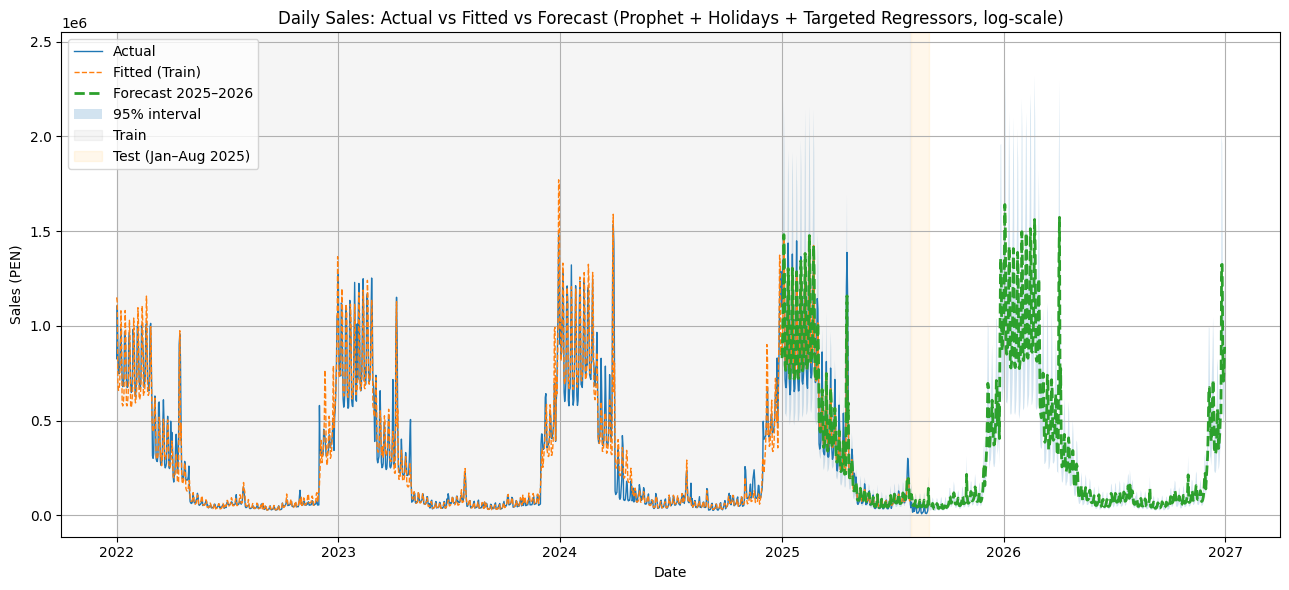

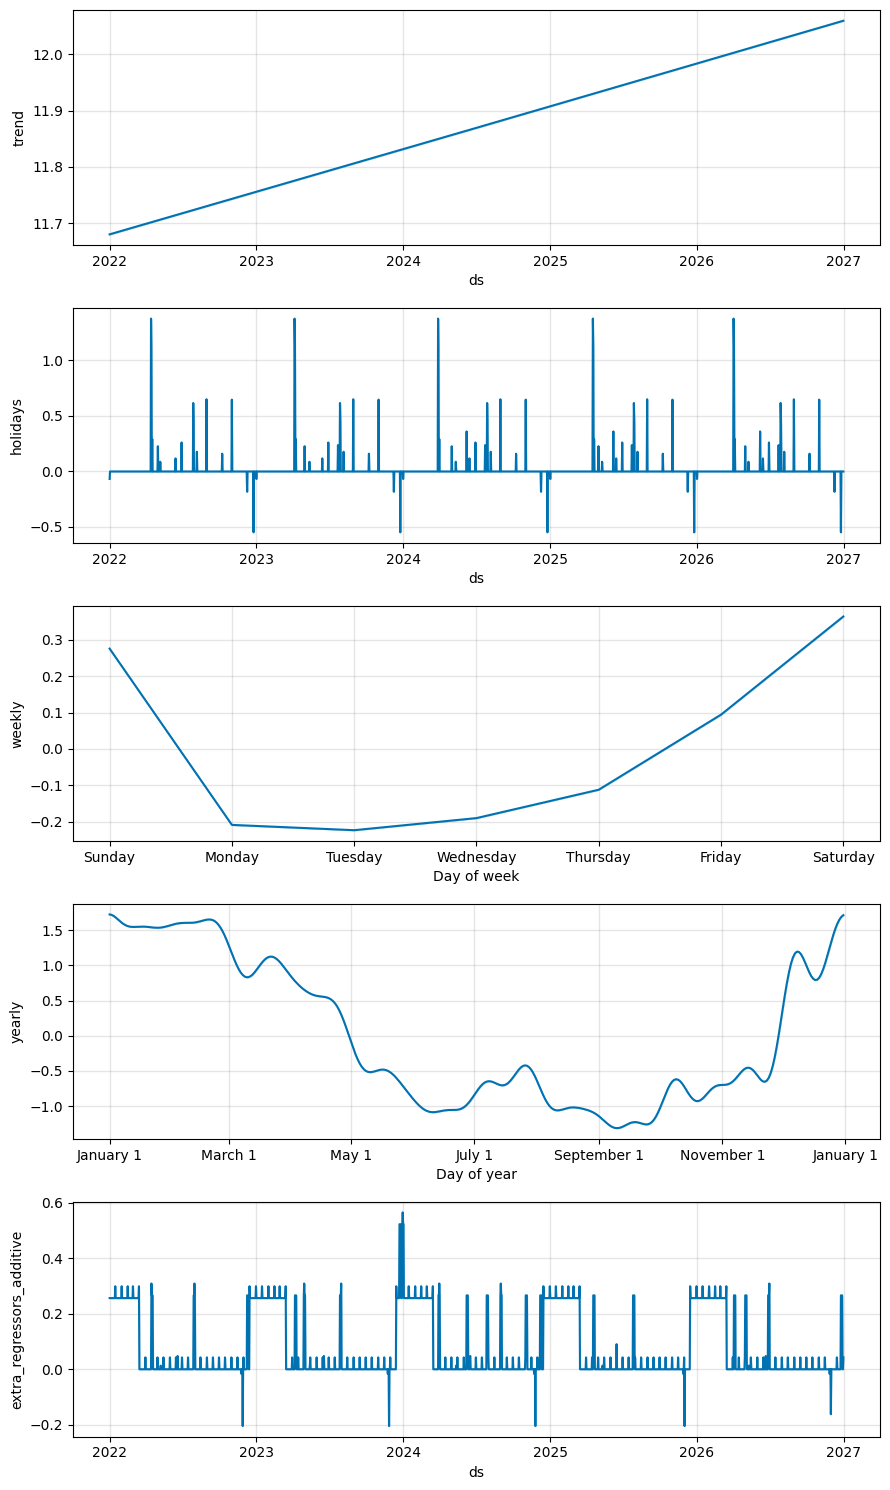

Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.
Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.

Top 25 days by absolute error:
             ds           y          yhat        abs_err       ape
108 2025-04-19  1157120.73  4.899726e+05  667148.156018  0.576559
1   2025-01-02  1344394.32  9.538365e+05  390557.845361  0.290508
105 2025-04-16   497307.09  2.189006e+05  278406.470741  0.559828
58  2025-02-28  1143425.40  8.681414e+05  275283.956360  0.240754
0   2025-01-01  1099677.54  8.294099e+05  270267.624100  0.245770
106 2025-04-17  1202997.55  9.346316e+05  268365.911902  0.223081
107 2025-04-18  1387020.98  1.158065e+06  228956.302525  0.165071
4   2025-01-05  1097776.56  1.322979e+06  225202.558330  0.205144
46  2025-02-16  1082737.48  1.305869e+06  223131.517689  0.206081
44  2025-02-14  1274533.32  1.071870e+06  202663.462606  0.159010
66  2025-03-08   862019.98  6.635361e+05  198483.859025  0.230254
9   2025-01-10  1165993

In [ ]:
# @title Modelo Ventas BDA vf (Train hasta ultimo dia de data real, para uso de budgets. ignorar MAPE y demas, los reales cv metrics son de la vf-1)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from prophet import Prophet
from datetime import date, timedelta

# Ensure Prophet uses Pystan backend
os.environ['PROPHET_BACKEND'] = 'PYSTAN'

# ---------------------------------------------------
# 1) Load & aggregate DAILY (sum per calendar day)
# ---------------------------------------------------
# If your file has an extension, include it (e.g., "...xlsx")
df_raw = pd.read_excel("Ventas Reales hasta Agosto 31 2025.xlsx", usecols="D,H")
df_raw.columns = ["Fecha", "Monto Soles"]

df_raw["Fecha"] = pd.to_datetime(df_raw["Fecha"]).dt.floor("D")
df_raw["Monto Soles"] = pd.to_numeric(df_raw["Monto Soles"], errors="coerce").fillna(0.0)

df_daily = (
    df_raw.groupby("Fecha", as_index=False)["Monto Soles"]
          .sum()
          .rename(columns={"Fecha": "ds", "Monto Soles": "y"})
          .sort_values("ds")
)

# Make series continuous (fill missing days with 0)
full_idx = pd.date_range(df_daily["ds"].min(), df_daily["ds"].max(), freq="D")
df_daily = (
    df_daily.set_index("ds")
            .reindex(full_idx)
            .rename_axis("ds")
            .fillna({"y": 0.0})
            .reset_index()
)

# Hard guard against any accidental duplicate dates
df_daily = (df_daily
            .groupby("ds", as_index=False)["y"].sum()
            .sort_values("ds")
            .reset_index(drop=True))

# ---------------------------------------------------
# 2) Windows
# ---------------------------------------------------
train_start = pd.Timestamp("2022-01-01")
train_end   = pd.Timestamp("2025-07-31")
test_start  = pd.Timestamp("2025-08-01")
test_end    = pd.Timestamp("2025-08-31")
fcst_end    = pd.Timestamp("2026-12-31")

data_min = min(train_start, df_daily["ds"].min())
data_max = max(fcst_end, df_daily["ds"].max())
df_daily = df_daily[(df_daily["ds"] >= data_min) & (df_daily["ds"] <= data_max)].copy()

train_df = df_daily[(df_daily["ds"] >= train_start) & (df_daily["ds"] <= train_end)].copy()
test_df  = df_daily[(df_daily["ds"] >= test_start)  & (df_daily["ds"] <= test_end)].copy()

print(f"Training window: {train_df['ds'].min().date()} → {train_df['ds'].max().date()}  ({len(train_df)} days)")
print(f"Test window:     {test_df['ds'].min().date()}  → {test_df['ds'].max().date()}   ({len(test_df)} days)")

# ---------------------------------------------------
# 3) Log-transform target (multiplicative effects on original scale)
# ---------------------------------------------------
df_log = df_daily.copy()
df_log["y_log"] = np.log1p(df_log["y"])  # robust with zeros

# ---------------------------------------------------
# 3.1 Targeted regressors (inline; no external builder)
#       - paydays, vacation, long weekends, mothers/fathers day,
#         black friday, cyber monday
#       - simple weather (tmax, rain, hot-day)
# ---------------------------------------------------
years = list(range(train_start.year, fcst_end.year + 1))

# Helpers
def nth_weekday(y, m, weekday, n):  # Mon=0..Sun=6
    d = date(y, m, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return first + timedelta(weeks=n-1)

def mothers_day_pe(y):  # 2nd Sunday of May
    return pd.Timestamp(nth_weekday(y, 5, 6, 2))
def fathers_day_pe(y):  # 3rd Sunday of June
    return pd.Timestamp(nth_weekday(y, 6, 6, 3))
def black_friday(y):    # 4th Friday of Nov
    return pd.Timestamp(nth_weekday(y, 11, 4, 4))
def cyber_monday(y):
    return black_friday(y) + pd.Timedelta(days=3)

# Base frame for features
fe = pd.DataFrame({"ds": df_log["ds"].copy()})
fe["dow"] = fe["ds"].dt.weekday
fe["day"] = fe["ds"].dt.day

# Paydays: 15th or month-end
fe["is_payday"] = ((fe["day"] == 15) | (fe["ds"] == fe["ds"] + pd.offsets.MonthEnd(0))).astype(int)

# Vacation windows (Boulevard de Asia summer):
#   - Generic rule each year: Dec 15 (prev year) to Mar 15 (year)
#   - Plus explicit windows you asked for
fe["is_vacation"] = 0
# explicit windows
explicit_windows = [
    ("2025-01-01","2025-03-15"),
    ("2025-12-15","2026-03-10"),
]
for start, end in explicit_windows:
    mask = (fe["ds"] >= pd.to_datetime(start)) & (fe["ds"] <= pd.to_datetime(end))
    fe.loc[mask, "is_vacation"] = 1
# generic rule (covers 2022–2026 for robustness)
for y in years:
    start = pd.Timestamp(year=y-1, month=12, day=15)
    end   = pd.Timestamp(year=y,   month=3,  day=15)
    mask = (fe["ds"] >= start) & (fe["ds"] <= end)
    fe.loc[mask, "is_vacation"] = 1

# Holidays (Peru official) for long-weekend logic
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"]).dt.normalize()

fe["is_long_weekend"] = 0
holi = set(peru_holidays["ds"].tolist())
dsn = fe["ds"].dt.normalize()
fri_holi = dsn.isin(holi) & (fe["dow"] == 4)  # Friday
mon_holi = dsn.isin(holi) & (fe["dow"] == 0)  # Monday
win_days = set()
for d in dsn[fri_holi]:
    for k in [0,1,2,3]:   # Fri..Mon
        win_days.add(d + pd.Timedelta(days=k))
for d in dsn[mon_holi]:
    for k in [-2,-1,0,1]: # Sat..Tue
        win_days.add(d + pd.Timedelta(days=k))
fe.loc[dsn.isin(win_days), "is_long_weekend"] = 1

# Mother's/Father's Day; Black Friday/Cyber Monday
fe["is_mothers_day"] = 0
fe["is_fathers_day"] = 0
fe["is_black_friday"] = 0
fe["is_cyber_monday"] = 0
md = {y: mothers_day_pe(y) for y in years}
fd = {y: fathers_day_pe(y) for y in years}
bf = {y: black_friday(y) for y in years}
cm = {y: cyber_monday(y) for y in years}
fe.loc[fe["ds"].isin(list(md.values())), "is_mothers_day"] = 1
fe.loc[fe["ds"].isin(list(fd.values())), "is_fathers_day"] = 1
fe.loc[fe["ds"].isin(list(bf.values())), "is_black_friday"] = 1
fe.loc[fe["ds"].isin(list(cm.values())), "is_cyber_monday"] = 1

# Simple weather (attempt to load; else neutral)
# Expect columns: ds, tmax_c, rain_mm (daily)
fe["tmax_c"] = np.nan
fe["rain_mm"] = np.nan
fe["is_hot_day"] = 0
try:
    wdf = pd.read_excel("weather_daily.xlsx")  # or .csv if you prefer
    wdf["ds"] = pd.to_datetime(wdf["ds"])
    wdf = wdf[["ds","tmax_c","rain_mm"]].copy()
    wdf["tmax_c"] = pd.to_numeric(wdf["tmax_c"], errors="coerce")
    wdf["rain_mm"] = pd.to_numeric(wdf["rain_mm"], errors="coerce").fillna(0.0)
    # month-aware hot threshold (90th percentile per month)
    wdf["year"] = wdf["ds"].dt.year
    wdf["month"] = wdf["ds"].dt.month
    thr = wdf.groupby(["year","month"])["tmax_c"].transform(
        lambda s: s.quantile(0.90) if s.notna().any() else np.nan
    )
    wdf["is_hot_day"] = (wdf["tmax_c"] >= thr).astype(int)
    wdf = wdf[["ds","tmax_c","rain_mm","is_hot_day"]]
    fe = fe.merge(wdf, on="ds", how="left", suffixes=("","_w"))
    # prefer loaded where present
    for c in ["tmax_c","rain_mm","is_hot_day"]:
        fe[c] = fe[f"{c}_w"].combine_first(fe[c])
        if f"{c}_w" in fe.columns: fe.drop(columns=[f"{c}_w"], inplace=True)
except FileNotFoundError:
    pass

# Minimal imputation
if fe["tmax_c"].isna().all():
    fe["tmax_c"] = 0.0
else:
    fe["tmax_c"] = fe["tmax_c"].fillna(fe["tmax_c"].median())
if fe["rain_mm"].isna().all():
    fe["rain_mm"] = 0.0
else:
    fe["rain_mm"] = fe["rain_mm"].fillna(0.0)
fe["is_hot_day"] = fe["is_hot_day"].fillna(0).astype(int)

# Merge features back
df_log = df_log.merge(fe.drop(columns=["dow","day"]), on="ds", how="left")

# ---------------------------------------------------
# 4) Holidays: official Peru + custom retail pulses (taller, not wider)
# ---------------------------------------------------
years = list(range(train_start.year, fcst_end.year + 1))

# Official Peru holidays
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"])

# Remove Dec 8 so effect isn't split
peru_holidays = peru_holidays[
    ~((peru_holidays["ds"].dt.month == 12) & (peru_holidays["ds"].dt.day == 8))
]

# Helpers
def nth_weekday_h(y, m, weekday, n):  # Mon=0..Sun=6
    d = date(y, m, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return first + timedelta(weeks=n-1)

# Custom events across all years (Mother's Day SAT/SUN, Gratificacion day)
rows = []
for y in years:
    # Mother's Day: 2nd Sunday of May (Peru) — Saturday is the biggest retail day
    md_sun = nth_weekday_h(y, 5, 6, 2)
    rows += [
        {"holiday":"MothersDay_Sat","ds": pd.Timestamp(md_sun) - pd.Timedelta(days=1),
         "lower_window":0,"upper_window":0,"prior_scale":65},
        {"holiday":"MothersDay_Sun","ds": pd.Timestamp(md_sun),
         "lower_window":0,"upper_window":0,"prior_scale":25},
    ]
    # Gratificacion: June 14 (single-day)
    rows.append(
        {"holiday":"Gratificacion","ds": pd.Timestamp(f"{y}-06-14"),
         "lower_window":0,"upper_window":0,"prior_scale":30}
    )

custom = pd.DataFrame(rows)

# Single tall pulse for Dec 8 (Immaculate Conception)
dec8_boost = pd.DataFrame({
    "holiday": "Dec8_Boost",
    "ds": [pd.Timestamp(f"{y}-12-08") for y in years],
    "lower_window": 0,
    "upper_window": 0,
    "prior_scale": 110  # raise if still short (e.g., 120)
})

# Final holiday table
all_holidays = (
    pd.concat([peru_holidays, custom, dec8_boost], ignore_index=True)
      .drop_duplicates(subset=["holiday","ds"])
      .sort_values(["ds","holiday"])
      .reset_index(drop=True)
)

# ---------------------------------------------------
# 5) Model (additive in log-space → multiplicative on original scale)
#     + Register the new regressors
# ---------------------------------------------------
m = Prophet(
    holidays=all_holidays,       # per-row prior_scale overrides global
    holidays_prior_scale=30,     # (kept as you had it)
    yearly_seasonality=20,       # (kept)
    weekly_seasonality=6,        # (kept)
    daily_seasonality=False,
    seasonality_prior_scale=14.0,
    changepoint_prior_scale=0.001,  # (kept)
    changepoint_range=0.8,
    n_changepoints=25,
    interval_width=0.95,
    seasonality_mode="additive"
)

reg_cols = [
    "is_payday","is_vacation","is_long_weekend",
    "is_mothers_day","is_fathers_day","is_black_friday","is_cyber_monday",
    "tmax_c","rain_mm","is_hot_day"
]
prior_scales = {
    "is_payday": 10,
    "is_vacation": 25,
    "is_long_weekend": 12,
    "is_mothers_day": 10,
    "is_fathers_day": 10,
    "is_black_friday": 16,
    "is_cyber_monday": 16,
    "tmax_c": 5,
    "rain_mm": 6,
    "is_hot_day": 8,
}
for r in reg_cols:
    m.add_regressor(r, prior_scale=prior_scales.get(r, 10))

# Build CLEAN train_fit with regressors
train_fit = (
    df_log[(df_log["ds"] >= train_start) & (df_log["ds"] <= train_end)]
    [["ds","y_log"] + reg_cols]
    .rename(columns={"y_log":"y"})
    .copy()
)

# Assert uniqueness of ds for Prophet; auto-fix if needed
dupes = train_fit["ds"].duplicated().sum()
if dupes:
    print(f"[WARN] Found {dupes} duplicate ds in train_fit; aggregating duplicates.")
    train_fit = train_fit.groupby("ds", as_index=False).mean(numeric_only=True)

# Fit on LOG target with regressors
m.fit(train_fit)

# ---------------------------------------------------
# 6) Forecast through 2026-12-31 and back-transform
# ---------------------------------------------------
periods_needed = (fcst_end - train_end).days
future = m.make_future_dataframe(periods=periods_needed, freq="D", include_history=True)

# Attach regressors to 'future' (reuse 'fe' logic)
fut = pd.DataFrame({"ds": future["ds"].copy()})
fut["dow"] = fut["ds"].dt.weekday
fut["day"] = fut["ds"].dt.day
fut["is_payday"] = ((fut["day"] == 15) | (fut["ds"] == fut["ds"] + pd.offsets.MonthEnd(0))).astype(int)
fut["is_vacation"] = 0
for start, end in explicit_windows:
    mask = (fut["ds"] >= pd.to_datetime(start)) & (fut["ds"] <= pd.to_datetime(end))
    fut.loc[mask, "is_vacation"] = 1
for y in years:
    start = pd.Timestamp(year=y-1, month=12, day=15)
    end   = pd.Timestamp(year=y,   month=3,  day=15)
    mask = (fut["ds"] >= start) & (fut["ds"] <= end)
    fut.loc[mask, "is_vacation"] = 1

# long weekends for future (reuse peru_holidays already built)
dsn_fut = fut["ds"].dt.normalize()
fut["is_long_weekend"] = 0
fri_holi = dsn_fut.isin(set(peru_holidays["ds"])) & (fut["dow"] == 4)
mon_holi = dsn_fut.isin(set(peru_holidays["ds"])) & (fut["dow"] == 0)
win_days = set()
for d in dsn_fut[fri_holi]:
    for k in [0,1,2,3]: win_days.add(d + pd.Timedelta(days=k))
for d in dsn_fut[mon_holi]:
    for k in [-2,-1,0,1]: win_days.add(d + pd.Timedelta(days=k))
fut.loc[dsn_fut.isin(win_days), "is_long_weekend"] = 1

# Mother/Father Day + BF/CM for future
fut["is_mothers_day"] = 0
fut["is_fathers_day"] = 0
fut["is_black_friday"] = 0
fut["is_cyber_monday"] = 0
fut.loc[fut["ds"].isin(list(md.values())), "is_mothers_day"] = 1
fut.loc[fut["ds"].isin(list(fd.values())), "is_fathers_day"] = 1
fut.loc[fut["ds"].isin(list(bf.values())), "is_black_friday"] = 1
fut.loc[fut["ds"].isin(list(cm.values())), "is_cyber_monday"] = 1

# Future weather:
# If you have a forecast file, merge it the same way as above and compute is_hot_day.
# Otherwise, set neutral (median) values and no hot days:
fut["tmax_c"] = fe["tmax_c"].median()
fut["rain_mm"] = fe["rain_mm"].median()
fut["is_hot_day"] = 0

future = future.merge(fut[["ds"] + reg_cols], on="ds", how="left")

# Predict
forecast = m.predict(future)

# Back-transform to original units
forecast["yhat"]       = np.expm1(forecast["yhat"])
forecast["yhat_lower"] = np.expm1(forecast["yhat_lower"])
forecast["yhat_upper"] = np.expm1(forecast["yhat_upper"])

# ---------------------------------------------------
# 7) Evaluation (Test: 2025-01-01 → 2025-08-31)
# ---------------------------------------------------
pred_test = forecast[(forecast["ds"] >= test_start) & (forecast["ds"] <= test_end)][
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].merge(test_df, on="ds", how="inner")

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def mape_pct(a, b, eps=1e-8):
    mask = np.abs(a) > eps
    return float(np.mean(np.abs((a[mask]-b[mask]) / a[mask]))*100) if mask.sum() else np.nan

test_mae  = mae(pred_test["y"].values,   pred_test["yhat"].values)
test_rmse = rmse(pred_test["y"].values,  pred_test["yhat"].values)
test_mape = mape_pct(pred_test["y"].values, pred_test["yhat"].values)

print("\n=== Test metrics (Daily, Jan–Aug 2025) ===")
print(f"MAE   : {test_mae:,.2f}")
print(f"RMSE  : {test_rmse:,.2f}")
print(f"MAPE% : {test_mape:,.2f}")

wape = np.abs(pred_test["y"] - pred_test["yhat"]).sum() / pred_test["y"].sum()
print("WAPE:", round(100*wape,2), "%")

# ---------------------------------------------------
# 8) Plots
# ---------------------------------------------------
plt.figure(figsize=(13,6))
plt.plot(df_daily["ds"], df_daily["y"], label="Actual", linewidth=1)

# In-sample fitted (back-transformed)
fitted_hist = forecast[(forecast["ds"] >= train_start) & (forecast["ds"] <= train_end)]
plt.plot(fitted_hist["ds"], fitted_hist["yhat"], label="Fitted (Train)", linestyle="--", linewidth=1)

# Forecast 2025–2026
fcst_horiz = forecast[(forecast["ds"] >= pd.Timestamp("2025-01-01")) & (forecast["ds"] <= fcst_end)]
plt.plot(fcst_horiz["ds"], fcst_horiz["yhat"], label="Forecast 2025–2026", linestyle="--", linewidth=2)
plt.fill_between(fcst_horiz["ds"], fcst_horiz["yhat_upper"], fcst_horiz["yhat_lower"], alpha=0.2, label="95% interval")

# Shade train/test
plt.axvspan(train_start, train_end, color="grey", alpha=0.08, label="Train")
plt.axvspan(test_start,  test_end,  color="orange", alpha=0.08, label="Test (Jan–Aug 2025)")

plt.title("Daily Sales: Actual vs Fitted vs Forecast (Prophet + Holidays + Targeted Regressors, log-scale)")
plt.xlabel("Date"); plt.ylabel("Sales (PEN)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Components
m.plot_components(forecast); plt.tight_layout(); plt.show()

# ---------------------------------------------------
# 9) Exports
# ---------------------------------------------------
out = fcst_horiz.copy()
out["deseasonalized"] = out["trend"]  # trend was modeled in log-space
out_cols = ["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "deseasonalized"]
out[out_cols].to_excel("prophet_forecast_2025_2026_daily.xlsx", index=False)
print("Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.")

monthly_2526 = (
    out.set_index("ds")[["yhat","yhat_lower","yhat_upper","trend"]]
      .resample("MS").sum(min_count=1)
      .reset_index()
)
monthly_2526.to_excel("prophet_forecast_2025_2026_monthly_from_daily.xlsx", index=False)
print("Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.")

# ---------------------------------------------------
# 10) Peak diagnostics (optional)
# ---------------------------------------------------
mask = (forecast["ds"] >= "2025-01-01") & (forecast["ds"] <= "2026-12-31")
pred = forecast.loc[mask, ["ds","yhat","yhat_lower","yhat_upper"]].merge(df_daily[["ds","y"]], on="ds", how="left")
pred["err"] = pred["y"] - pred["yhat"]
pred["abs_err"] = pred["err"].abs()
pred["squared_err"] = pred["err"]**2
pred["ape"] = pred["abs_err"] / np.where(pred["y"].abs()>1e-8, pred["y"], np.nan)

top_abs = pred.nlargest(25, "abs_err")[["ds","y","yhat","abs_err","ape"]]
print("\nTop 25 days by absolute error:\n", top_abs)

# Map events
ev_map = (all_holidays.groupby("ds")["holiday"]
                 .apply(lambda s: ",".join(sorted(set(s))))
                 .reset_index()
                 .rename(columns={"holiday":"event"}))
top_with_events = top_abs.merge(ev_map, on="ds", how="left")
print("\nTop 25 with event labels:\n", top_with_events[["ds","event","y","yhat","abs_err","ape"]])

# Check Dec 8 heights by year
for yr in [2022, 2023, 2024, 2025, 2026]:
    row = forecast.loc[forecast["ds"] == pd.Timestamp(f"{yr}-12-08"), ["ds","yhat","holidays","trend"]]
    print(row.to_string(index=False))


Training window: 2022-01-01 → 2024-12-31  (1096 days)
Test window:     2025-01-01  → 2025-07-31   (212 days)


DEBUG:cmdstanpy:input tempfile: /tmp/tmpgqugtg7r/p9d0noo1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpgqugtg7r/9q9j073v.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=18369', 'data', 'file=/tmp/tmpgqugtg7r/p9d0noo1.json', 'init=/tmp/tmpgqugtg7r/9q9j073v.json', 'output', 'file=/tmp/tmpgqugtg7r/prophet_model35xpla4_/prophet_model-20251024181017.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:10:17 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:10:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



=== Test metrics (Daily, Jan–Jul 2025) ===
MAE   : 60,690.56
RMSE  : 101,247.10
MAPE% : 15.39


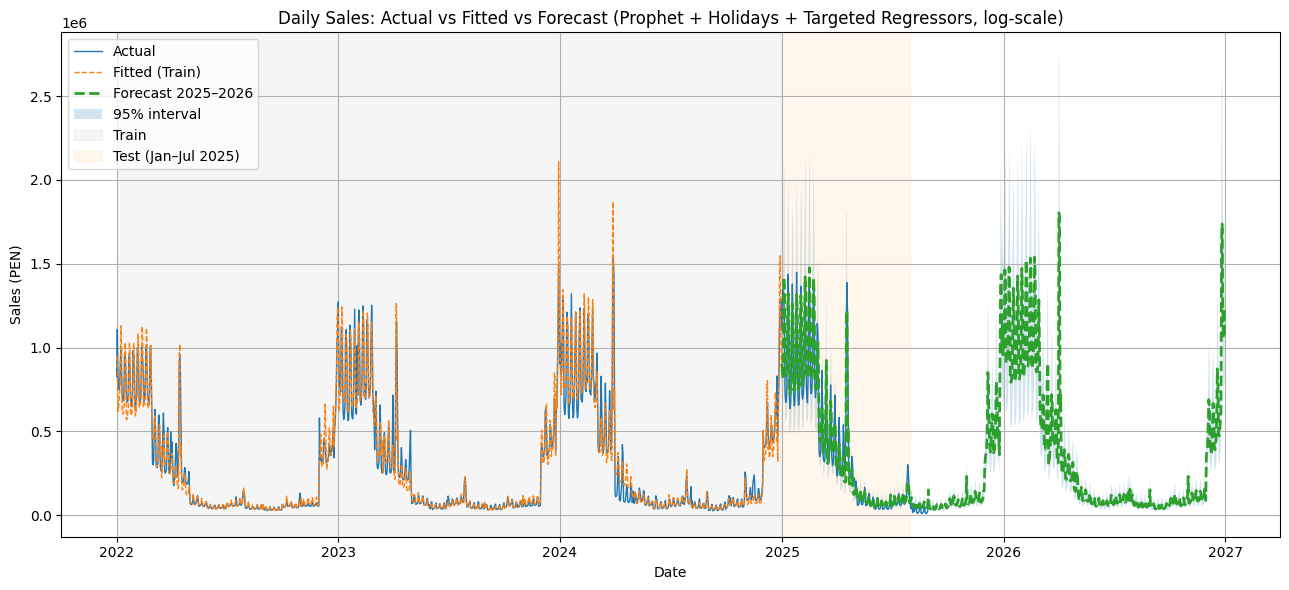

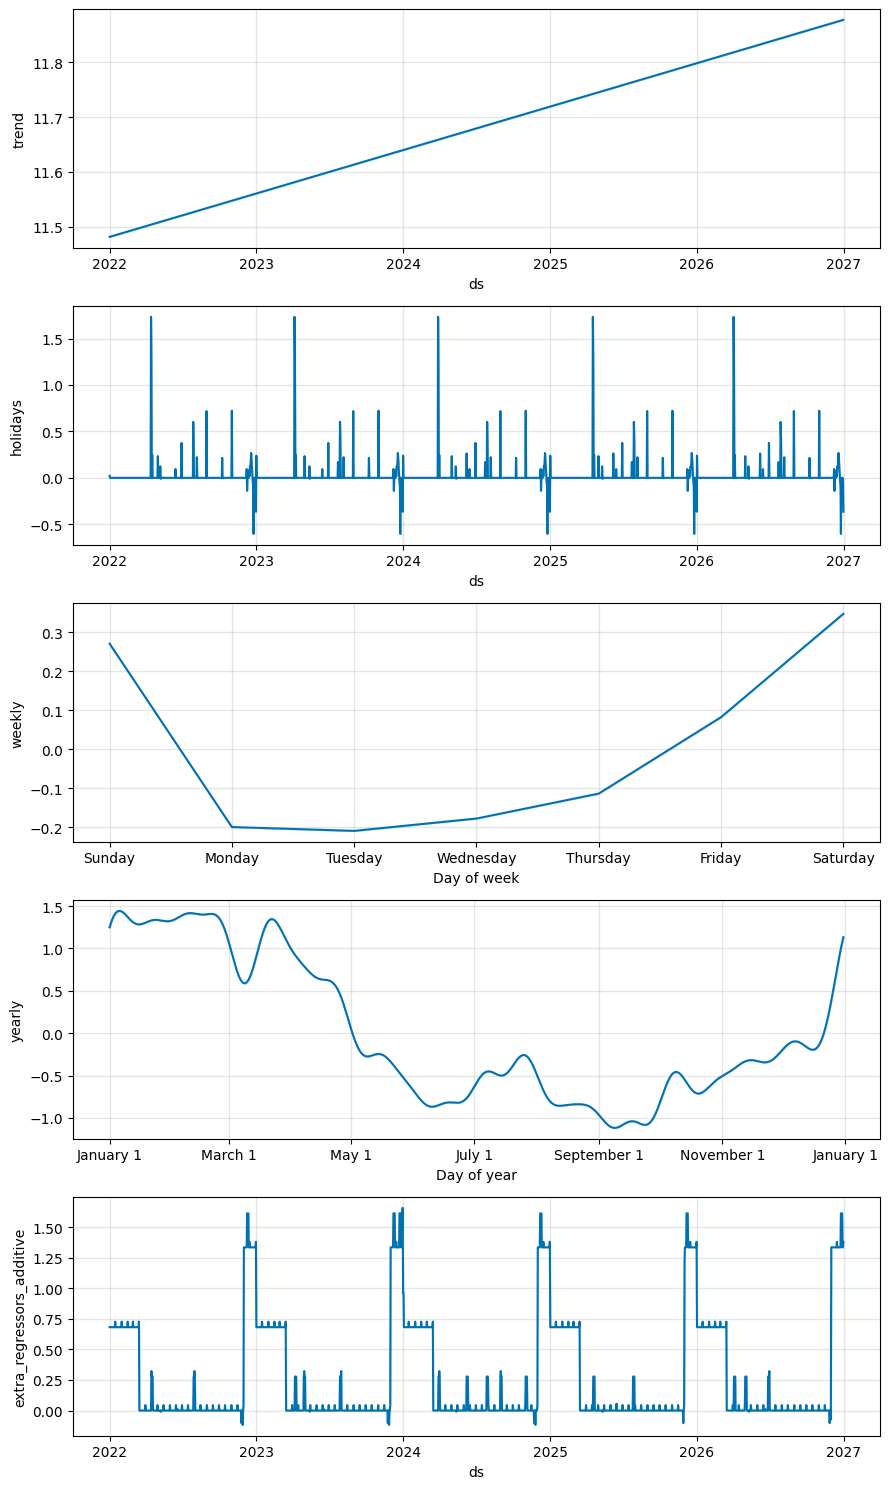

Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.
Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.

Top 25 days by absolute error:
             ds           y          yhat        abs_err       ape
108 2025-04-19  1157120.73  4.399996e+05  717121.088474  0.619746
1   2025-01-02  1344394.32  8.166352e+05  527759.169497  0.392563
105 2025-04-16   497307.09  1.988805e+05  298426.602972  0.600085
58  2025-02-28  1143425.40  8.938453e+05  249580.058547  0.218274
4   2025-01-05  1097776.56  1.344735e+06  246958.860550  0.224963
66  2025-03-08   862019.98  6.343324e+05  227687.608207  0.264133
2   2025-01-03  1274274.83  1.050432e+06  223843.329516  0.175663
46  2025-02-16  1082737.48  1.305453e+06  222715.573326  0.205697
0   2025-01-01  1099677.54  9.022220e+05  197455.551459  0.179558
16  2025-01-17  1151283.95  9.615031e+05  189780.824405  0.164843
44  2025-02-14  1274533.32  1.086322e+06  188211.336228  0.147671
101 2025-04-12   538652

In [ ]:
# @title Modelo Ventas Ag BDA Dec Rescaled
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from prophet import Prophet
from datetime import date

# Ensure Prophet uses Pystan backend
os.environ['PROPHET_BACKEND'] = 'PYSTAN'

# ---------------------------------------------------
# 1) Load & aggregate DAILY (sum per calendar day)
# ---------------------------------------------------
df_raw = pd.read_excel("Ventas Reales hasta Agosto 31 2025.xlsx", usecols="D,H")
df_raw.columns = ["Fecha", "Monto Soles"]

df_raw["Fecha"] = pd.to_datetime(df_raw["Fecha"]).dt.floor("D")
df_raw["Monto Soles"] = pd.to_numeric(df_raw["Monto Soles"], errors="coerce").fillna(0.0)

df_daily = (
    df_raw.groupby("Fecha", as_index=False)["Monto Soles"]
          .sum()
          .rename(columns={"Fecha": "ds", "Monto Soles": "y"})
          .sort_values("ds")
)

# Make series continuous (fill missing days with 0)
full_idx = pd.date_range(df_daily["ds"].min(), df_daily["ds"].max(), freq="D")
df_daily = (
    df_daily.set_index("ds")
            .reindex(full_idx)
            .rename_axis("ds")
            .fillna({"y": 0.0})
            .reset_index()
)

# Hard guard against any accidental duplicate dates
df_daily = (df_daily
            .groupby("ds", as_index=False)["y"].sum()
            .sort_values("ds")
            .reset_index(drop=True))

# ---------------------------------------------------
# 2) Windows
# ---------------------------------------------------
train_start = pd.Timestamp("2022-01-01")
train_end   = pd.Timestamp("2024-12-31")
test_start  = pd.Timestamp("2025-01-01")
test_end    = pd.Timestamp("2025-07-31")  # keep Aug out due to known issues
fcst_end    = pd.Timestamp("2026-12-31")

data_min = min(train_start, df_daily["ds"].min())
data_max = max(fcst_end, df_daily["ds"].max())
df_daily = df_daily[(df_daily["ds"] >= data_min) & (df_daily["ds"] <= data_max)].copy()

train_df = df_daily[(df_daily["ds"] >= train_start) & (df_daily["ds"] <= train_end)].copy()
test_df  = df_daily[(df_daily["ds"] >= test_start)  & (df_daily["ds"] <= test_end)].copy()

print(f"Training window: {train_df['ds'].min().date()} → {train_df['ds'].max().date()}  ({len(train_df)} days)")
print(f"Test window:     {test_df['ds'].min().date()}  → {test_df['ds'].max().date()}   ({len(test_df)} days)")

# ---------------------------------------------------
# 3) Log-transform target (multiplicative effects on original scale)
# ---------------------------------------------------
df_log = df_daily.copy()
df_log["y_log"] = np.log1p(df_log["y"])  # robust with zeros

# ---------------------------------------------------
# 3.1 Targeted regressors (inline; no external builder)
# ---------------------------------------------------
# years: for holidays and fixed-date events within data & forecast horizon
years = list(range(train_start.year, fcst_end.year + 1))
# years_span: for windows that cross year boundary (e.g., Dec Y-1 → Mar Y)
# include +1 year to cover Dec of the last forecast year (Dec-2026 → Mar-2027)
years_span = list(range(train_start.year, fcst_end.year + 2))

# Helpers
def nth_weekday(y, m, weekday, n):  # Mon=0..Sun=6
    d = date(y, m, 1)
    shift = (weekday - d.weekday()) % 7
    first = pd.Timestamp(d) + pd.Timedelta(days=shift)
    return first + pd.Timedelta(weeks=n-1)

def mothers_day_pe(y):  # 2nd Sunday of May
    return nth_weekday(y, 5, 6, 2)
def fathers_day_pe(y):  # 3rd Sunday of June
    return nth_weekday(y, 6, 6, 3)
def black_friday(y):    # 4th Friday of Nov
    return nth_weekday(y, 11, 4, 4)
def cyber_monday(y):
    return black_friday(y) + pd.Timedelta(days=3)

# Base frame for features
fe = pd.DataFrame({"ds": df_log["ds"].copy()})
fe["dow"] = fe["ds"].dt.weekday
fe["day"] = fe["ds"].dt.day

# Paydays: 15th or month-end
fe["is_payday"] = ((fe["day"] == 15) | (fe["ds"] == fe["ds"] + pd.offsets.MonthEnd(0))).astype(int)

# Vacation windows (start Dec 1, end Mar 15) — use years_span to cover Dec-2026
fe["is_vacation"] = 0
explicit_windows = [
    ("2025-01-01","2025-03-15"),
    ("2025-12-15","2026-03-10"),
    ("2026-12-01","2027-03-15"),  # safety for last season overlap
]
for start, end in explicit_windows:
    mask = (fe["ds"] >= pd.to_datetime(start)) & (fe["ds"] <= pd.to_datetime(end))
    fe.loc[mask, "is_vacation"] = 1
for y in years_span:
    start = pd.Timestamp(year=y-1, month=12, day=1)   # Dec 1
    end   = pd.Timestamp(year=y,   month=3,  day=15)
    mask = (fe["ds"] >= start) & (fe["ds"] <= end)
    fe.loc[mask, "is_vacation"] = 1

# Long weekends from Peru official holidays
peru_h_days = pd.DataFrame(
    [(d, n) for yy in years for d, n in holidays.Peru(years=yy).items()],
    columns=["ds", "holiday"]
)
peru_h_days["ds"] = pd.to_datetime(peru_h_days["ds"]).dt.normalize()

fe["is_long_weekend"] = 0
holi = set(peru_h_days["ds"].tolist())
dsn = fe["ds"].dt.normalize()
fri_holi = dsn.isin(holi) & (fe["dow"] == 4)  # Friday
mon_holi = dsn.isin(holi) & (fe["dow"] == 0)  # Monday
win_days = set()
for d in dsn[fri_holi]:
    for k in [0,1,2,3]:   # Fri..Mon
        win_days.add(d + pd.Timedelta(days=k))
for d in dsn[mon_holi]:
    for k in [-2,-1,0,1]: # Sat..Tue
        win_days.add(d + pd.Timedelta(days=k))
fe.loc[dsn.isin(win_days), "is_long_weekend"] = 1

# Mother/Father Day; BF/CM
fe["is_mothers_day"] = 0
fe["is_fathers_day"] = 0
fe["is_black_friday"] = 0
fe["is_cyber_monday"] = 0
md = {y: mothers_day_pe(y) for y in years}
fd = {y: fathers_day_pe(y) for y in years}
bf = {y: black_friday(y) for y in years}
cm = {y: cyber_monday(y) for y in years}
fe.loc[fe["ds"].isin(list(md.values())), "is_mothers_day"] = 1
fe.loc[fe["ds"].isin(list(fd.values())), "is_fathers_day"] = 1
fe.loc[fe["ds"].isin(list(bf.values())), "is_black_friday"] = 1
fe.loc[fe["ds"].isin(list(cm.values())), "is_cyber_monday"] = 1

# Gentle December flag
fe["is_december"] = (fe["ds"].dt.month == 12).astype(int)

# Simple weather (attempt to load; else neutral)
fe["tmax_c"] = np.nan
fe["rain_mm"] = np.nan
fe["is_hot_day"] = 0
weather_loaded = False
try:
    wdf = pd.read_excel("weather_daily.xlsx")  # expects columns: ds, tmax_c, rain_mm
    wdf["ds"] = pd.to_datetime(wdf["ds"])
    wdf = wdf[["ds","tmax_c","rain_mm"]].copy()
    wdf["tmax_c"] = pd.to_numeric(wdf["tmax_c"], errors="coerce")
    wdf["rain_mm"] = pd.to_numeric(wdf["rain_mm"], errors="coerce").fillna(0.0)
    # month-aware hot threshold (90th percentile per month)
    wdf["year"] = wdf["ds"].dt.year
    wdf["month"] = wdf["ds"].dt.month
    thr = wdf.groupby(["year","month"])["tmax_c"].transform(
        lambda s: s.quantile(0.90) if s.notna().any() else np.nan
    )
    wdf["is_hot_day"] = (wdf["tmax_c"] >= thr).astype(int)
    wdf = wdf[["ds","tmax_c","rain_mm","is_hot_day"]]
    fe = fe.merge(wdf, on="ds", how="left", suffixes=("","_w"))
    # prefer loaded where present
    for c in ["tmax_c","rain_mm","is_hot_day"]:
        fe[c] = fe[f"{c}_w"].combine_first(fe[c])
        if f"{c}_w" in fe.columns: fe.drop(columns=[f"{c}_w"], inplace=True)
    weather_loaded = True
except FileNotFoundError:
    pass

# Minimal imputation
if weather_loaded:
    fe["tmax_c"] = fe["tmax_c"].fillna(fe["tmax_c"].median())
    fe["rain_mm"] = fe["rain_mm"].fillna(0.0)
else:
    fe["tmax_c"] = 0.0
    fe["rain_mm"] = 0.0
fe["is_hot_day"] = fe["is_hot_day"].fillna(0).astype(int)

# Merge features back
df_log = df_log.merge(fe.drop(columns=["dow","day"]), on="ds", how="left")

# ---------------------------------------------------
# 4) Holidays: Peru + custom retail pulses (incl. stronger December)
# ---------------------------------------------------
# Official Peru holidays (for Prophet 'holidays' table)
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"])

# Remove Dec 8 so effect isn't split (we add a single tall pulse below)
peru_holidays = peru_holidays[
    ~((peru_holidays["ds"].dt.month == 12) & (peru_holidays["ds"].dt.day == 8))
]

rows = []
for y in years:
    # Mother's Day: 2nd Sunday of May — Saturday is usually bigger
    md_sun = nth_weekday(y, 5, 6, 2)
    rows += [
        {"holiday":"MothersDay_Sat","ds": pd.Timestamp(md_sun) - pd.Timedelta(days=1),
         "lower_window":0,"upper_window":0,"prior_scale":65},
        {"holiday":"MothersDay_Sun","ds": pd.Timestamp(md_sun),
         "lower_window":0,"upper_window":0,"prior_scale":25},
    ]
    # Gratificacion: June 14 (single-day)
    rows.append(
        {"holiday":"Gratificacion_Jun","ds": pd.Timestamp(f"{y}-06-14"),
         "lower_window":0,"upper_window":0,"prior_scale":30}
    )
    # December pulses
    rows.append({
        "holiday":"Gratificacion_Dec",
        "ds": pd.Timestamp(f"{y}-12-15"),
        "lower_window":0,"upper_window":0,"prior_scale":50
    })
    rows.append({
        "holiday":"XmasRamp",
        "ds": pd.Timestamp(f"{y}-12-24"),
        "lower_window":-10,"upper_window":0,"prior_scale":55
    })
    rows.append({
        "holiday":"NewYearRamp",
        "ds": pd.Timestamp(f"{y}-12-31"),
        "lower_window":-3,"upper_window":1,"prior_scale":25
    })

custom = pd.DataFrame(rows)

# Single tall pulse for Dec 8 (Immaculate Conception)
dec8_boost = pd.DataFrame({
    "holiday": "Dec8_Boost",
    "ds": [pd.Timestamp(f"{y}-12-08") for y in years],
    "lower_window": 0,
    "upper_window": 0,
    "prior_scale": 110
})

# Final holiday table
all_holidays = (
    pd.concat([peru_holidays, custom, dec8_boost], ignore_index=True)
      .drop_duplicates(subset=["holiday","ds"])
      .sort_values(["ds","holiday"])
      .reset_index(drop=True)
)

# ---------------------------------------------------
# 5) Model (additive in log-space → multiplicative on original scale)
#     + Register the regressors (incl. is_december)
# ---------------------------------------------------
m = Prophet(
    holidays=all_holidays,       # per-row prior_scale overrides global
    holidays_prior_scale=30,     # keep as in your best run
    yearly_seasonality=20,
    weekly_seasonality=6,
    daily_seasonality=False,
    seasonality_prior_scale=14.0,
    changepoint_prior_scale=0.001,
    changepoint_range=0.8,
    n_changepoints=25,
    interval_width=0.95,
    seasonality_mode="additive"
)

reg_cols = [
    "is_payday","is_vacation","is_long_weekend",
    "is_mothers_day","is_fathers_day","is_black_friday","is_cyber_monday",
    "is_december",
    "tmax_c","rain_mm","is_hot_day"
]
prior_scales = {
    "is_payday": 10,
    "is_vacation": 25,
    "is_long_weekend": 12,
    "is_mothers_day": 10,
    "is_fathers_day": 10,
    "is_black_friday": 16,
    "is_cyber_monday": 16,
    "is_december": 8,
    "tmax_c": 5,
    "rain_mm": 6,
    "is_hot_day": 8,
}
for r in reg_cols:
    m.add_regressor(r, prior_scale=prior_scales.get(r, 10))

# Build CLEAN train_fit with regressors
train_fit = (
    df_log[(df_log["ds"] >= train_start) & (df_log["ds"] <= train_end)]
    [["ds","y_log"] + reg_cols]
    .rename(columns={"y_log":"y"})
    .copy()
)

# Assert uniqueness of ds for Prophet; auto-fix if needed
dupes = train_fit["ds"].duplicated().sum()
if dupes:
    print(f"[WARN] Found {dupes} duplicate ds in train_fit; aggregating duplicates.")
    train_fit = train_fit.groupby("ds", as_index=False).mean(numeric_only=True)

# Fit on LOG target with regressors
m.fit(train_fit)

# ---------------------------------------------------
# 6) Forecast through 2026-12-31 and back-transform
# ---------------------------------------------------
periods_needed = (fcst_end - train_end).days
future = m.make_future_dataframe(periods=periods_needed, freq="D", include_history=True)

# Attach regressors to 'future' (reuse logic)
fut = pd.DataFrame({"ds": future["ds"].copy()})
fut["dow"] = fut["ds"].dt.weekday
fut["day"] = fut["ds"].dt.day
fut["is_payday"] = ((fut["day"] == 15) | (fut["ds"] == fut["ds"] + pd.offsets.MonthEnd(0))).astype(int)

# Vacation windows (use years_span here too)
fut["is_vacation"] = 0
for start, end in explicit_windows:
    mask = (fut["ds"] >= pd.to_datetime(start)) & (fut["ds"] <= pd.to_datetime(end))
    fut.loc[mask, "is_vacation"] = 1
for y in years_span:
    start = pd.Timestamp(year=y-1, month=12, day=1)   # Dec 1
    end   = pd.Timestamp(year=y,   month=3,  day=15)
    mask = (fut["ds"] >= start) & (fut["ds"] <= end)
    fut.loc[mask, "is_vacation"] = 1

# long weekends for future (using peru_h_days built earlier)
dsn_fut = fut["ds"].dt.normalize()
fut["is_long_weekend"] = 0
fri_holi = dsn_fut.isin(set(peru_h_days["ds"])) & (fut["dow"] == 4)
mon_holi = dsn_fut.isin(set(peru_h_days["ds"])) & (fut["dow"] == 0)
win_days = set()
for d in dsn_fut[fri_holi]:
    for k in [0,1,2,3]: win_days.add(d + pd.Timedelta(days=k))
for d in dsn_fut[mon_holi]:
    for k in [-2,-1,0,1]: win_days.add(d + pd.Timedelta(days=k))
fut.loc[dsn_fut.isin(win_days), "is_long_weekend"] = 1

# Mother/Father Day + BF/CM for future
fut["is_mothers_day"] = 0
fut["is_fathers_day"] = 0
fut["is_black_friday"] = 0
fut["is_cyber_monday"] = 0
fut.loc[fut["ds"].isin(list(md.values())), "is_mothers_day"] = 1
fut.loc[fut["ds"].isin(list(fd.values())), "is_fathers_day"] = 1
fut.loc[fut["ds"].isin(list(bf.values())), "is_black_friday"] = 1
fut.loc[fut["ds"].isin(list(cm.values())), "is_cyber_monday"] = 1

# December flag
fut["is_december"] = (fut["ds"].dt.month == 12).astype(int)

# Future weather:
if weather_loaded:
    # Monthly climatology from history
    hist = fe.dropna(subset=["tmax_c"]).copy()
    hist["m"] = hist["ds"].dt.month
    clim_tmax = hist.groupby("m")["tmax_c"].median()
    clim_rain = fe.assign(m=fe["ds"].dt.month).groupby("m")["rain_mm"].median()
    thr90 = hist.groupby("m")["tmax_c"].quantile(0.90)

    fut["m"] = fut["ds"].dt.month
    fut["tmax_c"]   = fut["m"].map(clim_tmax).astype(float)
    fut["rain_mm"]  = fut["m"].map(clim_rain).astype(float)
    fut["is_hot_day"] = (fut["tmax_c"] >= fut["m"].map(thr90)).astype(int)
    fut.drop(columns=["m"], inplace=True)
else:
    # Neutral fallback (no weather file)
    fut["tmax_c"]   = fe["tmax_c"].median()
    fut["rain_mm"]  = fe["rain_mm"].median()
    fut["is_hot_day"] = 0

future = future.merge(fut[["ds"] + reg_cols], on="ds", how="left")

# Predict
forecast = m.predict(future)

# Back-transform to original units
forecast["yhat"]       = np.expm1(forecast["yhat"])
forecast["yhat_lower"] = np.expm1(forecast["yhat_lower"])
forecast["yhat_upper"] = np.expm1(forecast["yhat_upper"])

# ---------------------------------------------------
# 7) Evaluation (Test: 2025-01-01 → 2025-07-31)
# ---------------------------------------------------
pred_test = forecast[(forecast["ds"] >= test_start) & (forecast["ds"] <= test_end)][
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].merge(test_df, on="ds", how="inner")

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def mape_pct(a, b, eps=1e-8):
    mask = np.abs(a) > eps
    return float(np.mean(np.abs((a[mask]-b[mask]) / a[mask]))*100) if mask.sum() else np.nan

test_mae  = mae(pred_test["y"].values,   pred_test["yhat"].values)
test_rmse = rmse(pred_test["y"].values,  pred_test["yhat"].values)
test_mape = mape_pct(pred_test["y"].values, pred_test["yhat"].values)

print("\n=== Test metrics (Daily, Jan–Jul 2025) ===")
print(f"MAE   : {test_mae:,.2f}")
print(f"RMSE  : {test_rmse:,.2f}")
print(f"MAPE% : {test_mape:,.2f}")

# ---------------------------------------------------
# 8) Plots
# ---------------------------------------------------
plt.figure(figsize=(13,6))
plt.plot(df_daily["ds"], df_daily["y"], label="Actual", linewidth=1)

# In-sample fitted (back-transformed)
fitted_hist = forecast[(forecast["ds"] >= train_start) & (forecast["ds"] <= train_end)]
plt.plot(fitted_hist["ds"], fitted_hist["yhat"], label="Fitted (Train)", linestyle="--", linewidth=1)

# Forecast 2025–2026
fcst_horiz = forecast[(forecast["ds"] >= pd.Timestamp("2025-01-01")) & (forecast["ds"] <= fcst_end)]
plt.plot(fcst_horiz["ds"], fcst_horiz["yhat"], label="Forecast 2025–2026", linestyle="--", linewidth=2)
plt.fill_between(fcst_horiz["ds"], fcst_horiz["yhat_upper"], fcst_horiz["yhat_lower"], alpha=0.2, label="95% interval")

# Shade train/test
plt.axvspan(train_start, train_end, color="grey", alpha=0.08, label="Train")
plt.axvspan(test_start,  test_end,  color="orange", alpha=0.08, label="Test (Jan–Jul 2025)")

plt.title("Daily Sales: Actual vs Fitted vs Forecast (Prophet + Holidays + Targeted Regressors, log-scale)")
plt.xlabel("Date"); plt.ylabel("Sales (PEN)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Components
m.plot_components(forecast); plt.tight_layout(); plt.show()

# ---------------------------------------------------
# 9) Exports
# ---------------------------------------------------
out = fcst_horiz.copy()
out["deseasonalized"] = out["trend"]  # trend was modeled in log-space
out_cols = ["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "deseasonalized"]
out[out_cols].to_excel("prophet_forecast_2025_2026_daily.xlsx", index=False)
print("Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.")

monthly_2526 = (
    out.set_index("ds")[["yhat","yhat_lower","yhat_upper","trend"]]
      .resample("MS").sum(min_count=1)
      .reset_index()
)
monthly_2526.to_excel("prophet_forecast_2025_2026_monthly_from_daily.xlsx", index=False)
print("Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.")

# ---------------------------------------------------
# 10) Peak diagnostics (optional)
# ---------------------------------------------------
mask = (forecast["ds"] >= "2025-01-01") & (forecast["ds"] <= "2026-12-31")
pred = forecast.loc[mask, ["ds","yhat","yhat_lower","yhat_upper"]].merge(df_daily[["ds","y"]], on="ds", how="left")
pred["err"] = pred["y"] - pred["yhat"]
pred["abs_err"] = pred["err"].abs()
pred["squared_err"] = pred["err"]**2
pred["ape"] = pred["abs_err"] / np.where(pred["y"].abs()>1e-8, pred["y"], np.nan)

top_abs = pred.nlargest(25, "abs_err")[["ds","y","yhat","abs_err","ape"]]
print("\nTop 25 days by absolute error:\n", top_abs)

# Map events
ev_map = (all_holidays.groupby("ds")["holiday"]
                 .apply(lambda s: ",".join(sorted(set(s))))
                 .reset_index()
                 .rename(columns={"holiday":"event"}))
top_with_events = top_abs.merge(ev_map, on="ds", how="left")
print("\nTop 25 with event labels:\n", top_with_events[["ds","event","y","yhat","abs_err","ape"]])

# ---------------------------------------------------
# 11) December bias check
# ---------------------------------------------------
def dec_summary(df_act, fcst):
    dec_act = (df_act[df_act["ds"].dt.month == 12]
               .assign(year=lambda d: d["ds"].dt.year)
               .groupby("year")["y"].sum()
               .rename("Dec_Actual"))
    dec_fc  = (fcst[fcst["ds"].dt.month == 12]
               .assign(year=lambda d: d["ds"].dt.year)
               .groupby("year")["yhat"].sum()
               .rename("Dec_Model"))
    out = pd.concat([dec_act, dec_fc], axis=1)
    out["Bias_%"] = 100*(out.get("Dec_Model") - out.get("Dec_Actual")) / out.get("Dec_Actual")
    return out

print("\n=== December bias check (actual vs model) ===")
print(dec_summary(df_daily, forecast))



DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/wpj2geof.json


Training window: 2022-01-01 → 2025-07-31  (1308 days)
Test window:     NaT  → NaT   (0 days)


DEBUG:cmdstanpy:input tempfile: /tmp/tmps71m1fph/pqw1px67.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67133', 'data', 'file=/tmp/tmps71m1fph/wpj2geof.json', 'init=/tmp/tmps71m1fph/pqw1px67.json', 'output', 'file=/tmp/tmps71m1fph/prophet_modelch9roapx/prophet_model-20251027170405.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:04:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:04:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtyp


=== Test metrics (Daily, Jan–Aug 2025) ===
MAE   : nan
RMSE  : nan
MAPE% : nan
WAPE: nan %


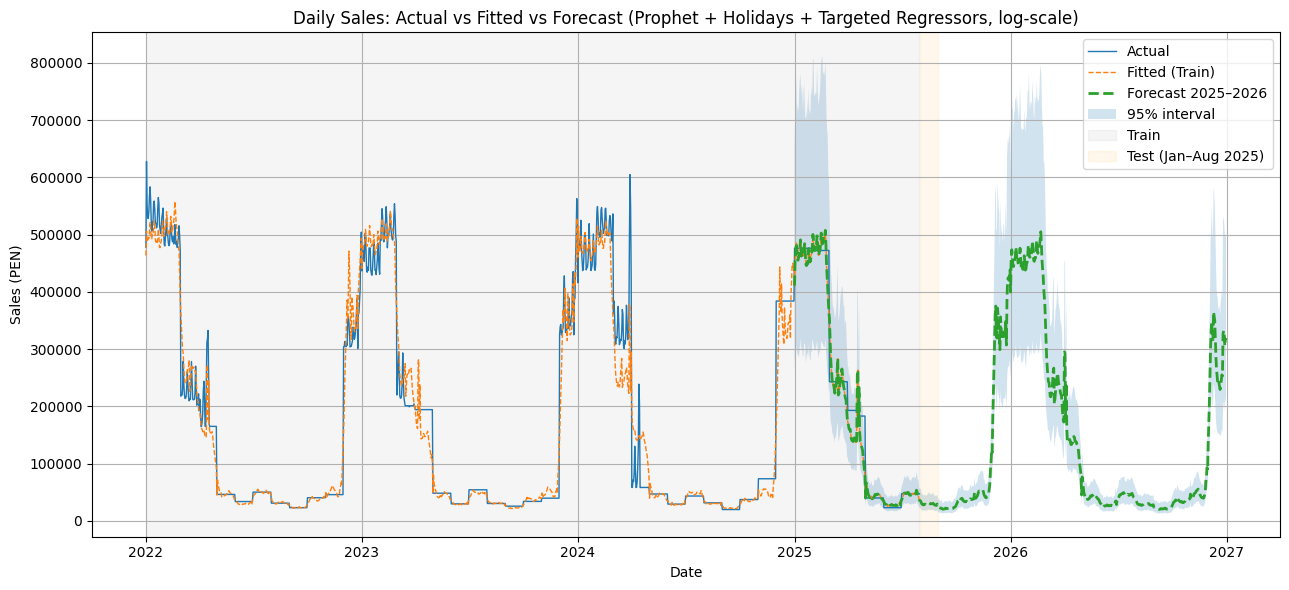

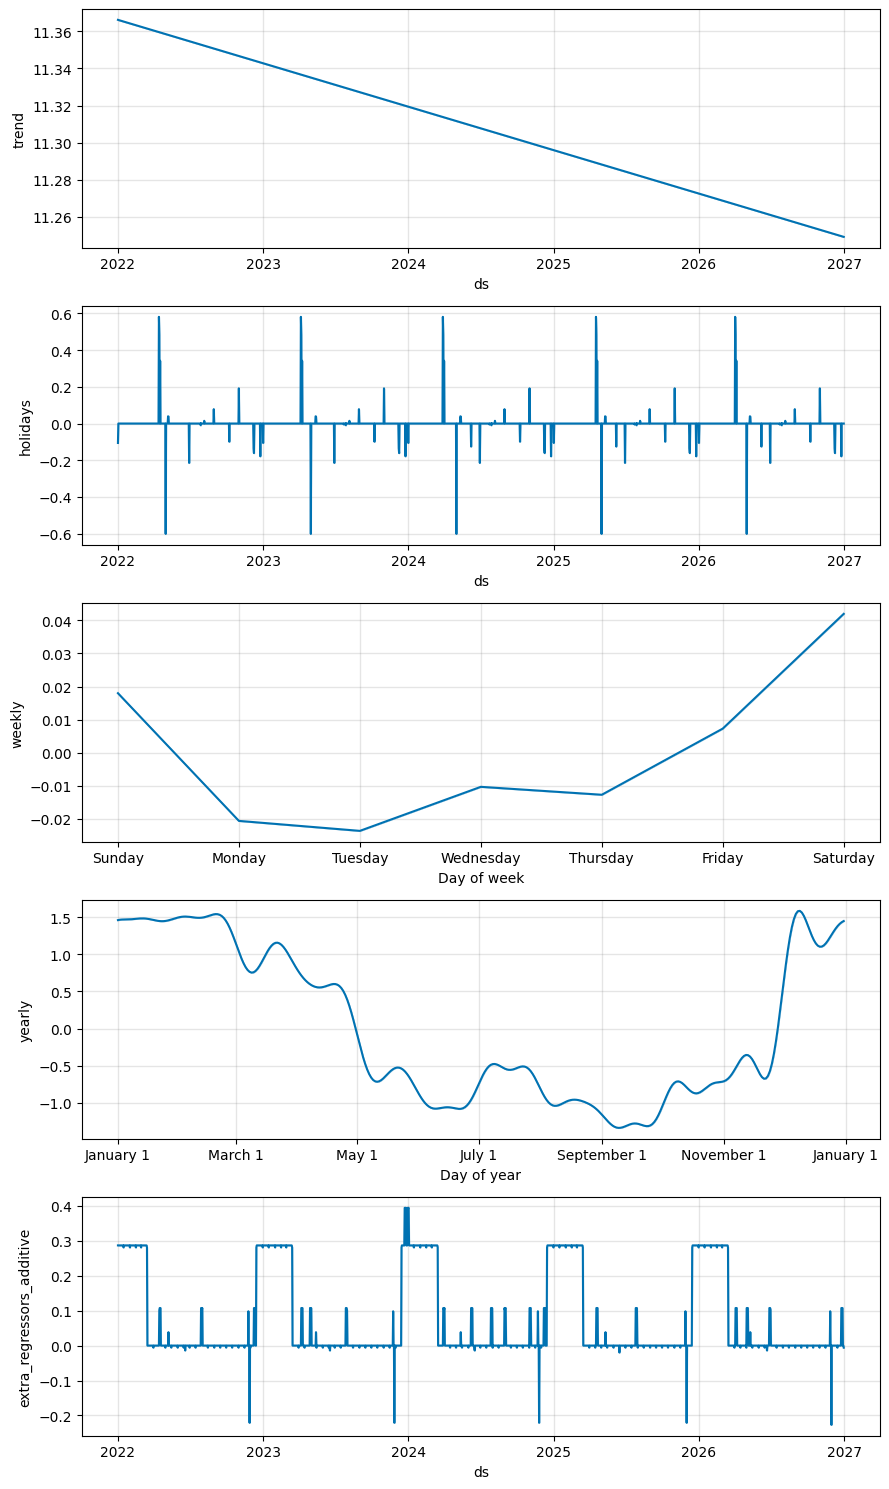

Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.
Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.

Top 25 days by absolute error:
             ds          y           yhat        abs_err       ape
59  2025-03-01  243080.62  353679.694250  110599.074250  0.454989
58  2025-02-28  472335.17  365215.227705  107119.942295  0.226788
119 2025-04-30  183109.88   80265.001171  102844.878829  0.561657
118 2025-04-29  183109.88   88340.960774   94768.919226  0.517552
57  2025-02-27  472335.17  385615.752628   86719.417372  0.183597
117 2025-04-28  183109.88   97659.390090   85450.489910  0.466662
60  2025-03-02  243080.62  320605.413974   77524.793974  0.318926
116 2025-04-27  183109.88  110909.967645   72199.912355  0.394298
107 2025-04-18  192931.12  263517.492296   70586.372296  0.365863
0   2025-01-01  476245.37  410939.489857   65305.880143  0.137127
89  2025-03-31  243080.62  179710.505500   63370.114500  0.260696
56  2025-02-26  472335.

In [ ]:
#@title Modelo BDA Ancla
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from prophet import Prophet
from datetime import date, timedelta

# Ensure Prophet uses Pystan backend
os.environ['PROPHET_BACKEND'] = 'PYSTAN'

# ---------------------------------------------------
# 1) Load & aggregate DAILY (sum per calendar day)
# ---------------------------------------------------
# If your file has an extension, include it (e.g., "...xlsx")
df_raw = pd.read_excel("Ventas Reales hasta Agosto 31 2025.xlsx", usecols="B,D,H")
df_raw.columns = ["Nombre","Fecha", "Monto Soles"]

###########################################


# Lista de marcas/tiendas a INCLUIR
BLOCK = ["RIPLEY", "WONG", "SODIMAC"]

# Patrón robusto: tolera mayúsc/minúsc, espacios múltiples y "H&M" / "H  &   M"
parts = []
for name in BLOCK:
    p = re.escape(name)
    p = p.replace(r"\ ", r"\s+")       # espacios flexibles
    p = p.replace(r"\&", r"\s*&\s*")  # '&' con espacios opcionales alrededor
    parts.append(rf"\b{p}\b")
pattern = "|".join(parts)

# INCLUIR solo filas que hagan match
mask_include = df_raw["Nombre"].astype(str).str.contains(pattern, regex=True, case=False, na=False)
df_raw = df_raw.loc[mask_include].copy()

# Si ya no necesitas el nombre después de filtrar:
df_raw = df_raw.drop(columns=["Nombre"])


###########################################

df_raw["Fecha"] = pd.to_datetime(df_raw["Fecha"]).dt.floor("D")
df_raw["Monto Soles"] = pd.to_numeric(df_raw["Monto Soles"], errors="coerce").fillna(0.0)

df_daily = (
    df_raw.groupby("Fecha", as_index=False)["Monto Soles"]
          .sum()
          .rename(columns={"Fecha": "ds", "Monto Soles": "y"})
          .sort_values("ds")
)

# Make series continuous (fill missing days with 0)
full_idx = pd.date_range(df_daily["ds"].min(), df_daily["ds"].max(), freq="D")
df_daily = (
    df_daily.set_index("ds")
            .reindex(full_idx)
            .rename_axis("ds")
            .fillna({"y": 0.0})
            .reset_index()
)

# Hard guard against any accidental duplicate dates
df_daily = (df_daily
            .groupby("ds", as_index=False)["y"].sum()
            .sort_values("ds")
            .reset_index(drop=True))

# ---------------------------------------------------
# 2) Windows
# ---------------------------------------------------
train_start = pd.Timestamp("2022-01-01")
train_end   = pd.Timestamp("2025-07-31")   #Used to be 2024-12-31
test_start  = pd.Timestamp("2025-08-01")   #Used to be 2025-01-01
test_end    = pd.Timestamp("2025-08-31")   #Used to be 2025-07-31
fcst_end    = pd.Timestamp("2026-12-31")

data_min = min(train_start, df_daily["ds"].min())
data_max = max(fcst_end, df_daily["ds"].max())
df_daily = df_daily[(df_daily["ds"] >= data_min) & (df_daily["ds"] <= data_max)].copy()

train_df = df_daily[(df_daily["ds"] >= train_start) & (df_daily["ds"] <= train_end)].copy()
test_df  = df_daily[(df_daily["ds"] >= test_start)  & (df_daily["ds"] <= test_end)].copy()

print(f"Training window: {train_df['ds'].min().date()} → {train_df['ds'].max().date()}  ({len(train_df)} days)")
print(f"Test window:     {test_df['ds'].min().date()}  → {test_df['ds'].max().date()}   ({len(test_df)} days)")

# ---------------------------------------------------
# 3) Log-transform target (multiplicative effects on original scale)
# ---------------------------------------------------
df_log = df_daily.copy()
df_log["y_log"] = np.log1p(df_log["y"])  # robust with zeros

# ---------------------------------------------------
# 3.1 Targeted regressors (inline; no external builder)
#       - paydays, vacation, long weekends, mothers/fathers day,
#         black friday, cyber monday
#       - simple weather (tmax, rain, hot-day)
# ---------------------------------------------------
years = list(range(train_start.year, fcst_end.year + 1))

# Helpers
def nth_weekday(y, m, weekday, n):  # Mon=0..Sun=6
    d = date(y, m, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return first + timedelta(weeks=n-1)

def mothers_day_pe(y):  # 2nd Sunday of May
    return pd.Timestamp(nth_weekday(y, 5, 6, 2))
def fathers_day_pe(y):  # 3rd Sunday of June
    return pd.Timestamp(nth_weekday(y, 6, 6, 3))
def black_friday(y):    # 4th Friday of Nov
    return pd.Timestamp(nth_weekday(y, 11, 4, 4))
def cyber_monday(y):
    return black_friday(y) + pd.Timedelta(days=3)

# Base frame for features
fe = pd.DataFrame({"ds": df_log["ds"].copy()})
fe["dow"] = fe["ds"].dt.weekday
fe["day"] = fe["ds"].dt.day

# Paydays: 15th or month-end
fe["is_payday"] = ((fe["day"] == 15) | (fe["ds"] == fe["ds"] + pd.offsets.MonthEnd(0))).astype(int)

# Vacation windows (Boulevard de Asia summer):
#   - Generic rule each year: Dec 15 (prev year) to Mar 15 (year)
#   - Plus explicit windows you asked for
fe["is_vacation"] = 0
# explicit windows
explicit_windows = [
    ("2025-01-01","2025-03-15"),
    ("2025-12-15","2026-03-10"),
]
for start, end in explicit_windows:
    mask = (fe["ds"] >= pd.to_datetime(start)) & (fe["ds"] <= pd.to_datetime(end))
    fe.loc[mask, "is_vacation"] = 1
# generic rule (covers 2022–2026 for robustness)
for y in years:
    start = pd.Timestamp(year=y-1, month=12, day=15)
    end   = pd.Timestamp(year=y,   month=3,  day=15)
    mask = (fe["ds"] >= start) & (fe["ds"] <= end)
    fe.loc[mask, "is_vacation"] = 1

# Holidays (Peru official) for long-weekend logic
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"]).dt.normalize()

fe["is_long_weekend"] = 0
holi = set(peru_holidays["ds"].tolist())
dsn = fe["ds"].dt.normalize()
fri_holi = dsn.isin(holi) & (fe["dow"] == 4)  # Friday
mon_holi = dsn.isin(holi) & (fe["dow"] == 0)  # Monday
win_days = set()
for d in dsn[fri_holi]:
    for k in [0,1,2,3]:   # Fri..Mon
        win_days.add(d + pd.Timedelta(days=k))
for d in dsn[mon_holi]:
    for k in [-2,-1,0,1]: # Sat..Tue
        win_days.add(d + pd.Timedelta(days=k))
fe.loc[dsn.isin(win_days), "is_long_weekend"] = 1

# Mother's/Father's Day; Black Friday/Cyber Monday
fe["is_mothers_day"] = 0
fe["is_fathers_day"] = 0
fe["is_black_friday"] = 0
fe["is_cyber_monday"] = 0
md = {y: mothers_day_pe(y) for y in years}
fd = {y: fathers_day_pe(y) for y in years}
bf = {y: black_friday(y) for y in years}
cm = {y: cyber_monday(y) for y in years}
fe.loc[fe["ds"].isin(list(md.values())), "is_mothers_day"] = 1
fe.loc[fe["ds"].isin(list(fd.values())), "is_fathers_day"] = 1
fe.loc[fe["ds"].isin(list(bf.values())), "is_black_friday"] = 1
fe.loc[fe["ds"].isin(list(cm.values())), "is_cyber_monday"] = 1

# Simple weather (attempt to load; else neutral)
# Expect columns: ds, tmax_c, rain_mm (daily)
fe["tmax_c"] = np.nan
fe["rain_mm"] = np.nan
fe["is_hot_day"] = 0
try:
    wdf = pd.read_excel("weather_daily.xlsx")  # or .csv if you prefer
    wdf["ds"] = pd.to_datetime(wdf["ds"])
    wdf = wdf[["ds","tmax_c","rain_mm"]].copy()
    wdf["tmax_c"] = pd.to_numeric(wdf["tmax_c"], errors="coerce")
    wdf["rain_mm"] = pd.to_numeric(wdf["rain_mm"], errors="coerce").fillna(0.0)
    # month-aware hot threshold (90th percentile per month)
    wdf["year"] = wdf["ds"].dt.year
    wdf["month"] = wdf["ds"].dt.month
    thr = wdf.groupby(["year","month"])["tmax_c"].transform(
        lambda s: s.quantile(0.90) if s.notna().any() else np.nan
    )
    wdf["is_hot_day"] = (wdf["tmax_c"] >= thr).astype(int)
    wdf = wdf[["ds","tmax_c","rain_mm","is_hot_day"]]
    fe = fe.merge(wdf, on="ds", how="left", suffixes=("","_w"))
    # prefer loaded where present
    for c in ["tmax_c","rain_mm","is_hot_day"]:
        fe[c] = fe[f"{c}_w"].combine_first(fe[c])
        if f"{c}_w" in fe.columns: fe.drop(columns=[f"{c}_w"], inplace=True)
except FileNotFoundError:
    pass

# Minimal imputation
if fe["tmax_c"].isna().all():
    fe["tmax_c"] = 0.0
else:
    fe["tmax_c"] = fe["tmax_c"].fillna(fe["tmax_c"].median())
if fe["rain_mm"].isna().all():
    fe["rain_mm"] = 0.0
else:
    fe["rain_mm"] = fe["rain_mm"].fillna(0.0)
fe["is_hot_day"] = fe["is_hot_day"].fillna(0).astype(int)

# Merge features back
df_log = df_log.merge(fe.drop(columns=["dow","day"]), on="ds", how="left")

# ---------------------------------------------------
# 4) Holidays: official Peru + custom retail pulses (taller, not wider)
# ---------------------------------------------------
years = list(range(train_start.year, fcst_end.year + 1))

# Official Peru holidays
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"])

# Remove Dec 8 so effect isn't split
peru_holidays = peru_holidays[
    ~((peru_holidays["ds"].dt.month == 12) & (peru_holidays["ds"].dt.day == 8))
]

# Helpers
def nth_weekday_h(y, m, weekday, n):  # Mon=0..Sun=6
    d = date(y, m, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return first + timedelta(weeks=n-1)

# Custom events across all years (Mother's Day SAT/SUN, Gratificacion day)
rows = []
for y in years:
    # Mother's Day: 2nd Sunday of May (Peru) — Saturday is the biggest retail day
    md_sun = nth_weekday_h(y, 5, 6, 2)
    rows += [
        {"holiday":"MothersDay_Sat","ds": pd.Timestamp(md_sun) - pd.Timedelta(days=1),
         "lower_window":0,"upper_window":0,"prior_scale":65},
        {"holiday":"MothersDay_Sun","ds": pd.Timestamp(md_sun),
         "lower_window":0,"upper_window":0,"prior_scale":25},
    ]
    # Gratificacion: June 14 (single-day)
    rows.append(
        {"holiday":"Gratificacion","ds": pd.Timestamp(f"{y}-06-14"),
         "lower_window":0,"upper_window":0,"prior_scale":30}
    )

custom = pd.DataFrame(rows)

# Single tall pulse for Dec 8 (Immaculate Conception)
dec8_boost = pd.DataFrame({
    "holiday": "Dec8_Boost",
    "ds": [pd.Timestamp(f"{y}-12-08") for y in years],
    "lower_window": 0,
    "upper_window": 0,
    "prior_scale": 110  # raise if still short (e.g., 120)
})

# Final holiday table
all_holidays = (
    pd.concat([peru_holidays, custom, dec8_boost], ignore_index=True)
      .drop_duplicates(subset=["holiday","ds"])
      .sort_values(["ds","holiday"])
      .reset_index(drop=True)
)

# ---------------------------------------------------
# 5) Model (additive in log-space → multiplicative on original scale)
#     + Register the new regressors
# ---------------------------------------------------
m = Prophet(
    holidays=all_holidays,       # per-row prior_scale overrides global
    holidays_prior_scale=30,     # (kept as you had it)
    yearly_seasonality=20,       # (kept)
    weekly_seasonality=6,        # (kept)
    daily_seasonality=False,
    seasonality_prior_scale=14.0,
    changepoint_prior_scale=0.001,  # (kept)
    changepoint_range=0.8,
    n_changepoints=25,
    interval_width=0.95,
    seasonality_mode="additive"
)

reg_cols = [
    "is_payday","is_vacation","is_long_weekend",
    "is_mothers_day","is_fathers_day","is_black_friday","is_cyber_monday",
    "tmax_c","rain_mm","is_hot_day"
]
prior_scales = {
    "is_payday": 10,
    "is_vacation": 25,
    "is_long_weekend": 12,
    "is_mothers_day": 10,
    "is_fathers_day": 10,
    "is_black_friday": 16,
    "is_cyber_monday": 16,
    "tmax_c": 5,
    "rain_mm": 6,
    "is_hot_day": 8,
}
for r in reg_cols:
    m.add_regressor(r, prior_scale=prior_scales.get(r, 10))

# Build CLEAN train_fit with regressors
train_fit = (
    df_log[(df_log["ds"] >= train_start) & (df_log["ds"] <= train_end)]
    [["ds","y_log"] + reg_cols]
    .rename(columns={"y_log":"y"})
    .copy()
)

# Assert uniqueness of ds for Prophet; auto-fix if needed
dupes = train_fit["ds"].duplicated().sum()
if dupes:
    print(f"[WARN] Found {dupes} duplicate ds in train_fit; aggregating duplicates.")
    train_fit = train_fit.groupby("ds", as_index=False).mean(numeric_only=True)

# Fit on LOG target with regressors
m.fit(train_fit)

# ---------------------------------------------------
# 6) Forecast through 2026-12-31 and back-transform
# ---------------------------------------------------
periods_needed = (fcst_end - train_end).days
future = m.make_future_dataframe(periods=periods_needed, freq="D", include_history=True)

# Attach regressors to 'future' (reuse 'fe' logic)
fut = pd.DataFrame({"ds": future["ds"].copy()})
fut["dow"] = fut["ds"].dt.weekday
fut["day"] = fut["ds"].dt.day
fut["is_payday"] = ((fut["day"] == 15) | (fut["ds"] == fut["ds"] + pd.offsets.MonthEnd(0))).astype(int)
fut["is_vacation"] = 0
for start, end in explicit_windows:
    mask = (fut["ds"] >= pd.to_datetime(start)) & (fut["ds"] <= pd.to_datetime(end))
    fut.loc[mask, "is_vacation"] = 1
for y in years:
    start = pd.Timestamp(year=y-1, month=12, day=15)
    end   = pd.Timestamp(year=y,   month=3,  day=15)
    mask = (fut["ds"] >= start) & (fut["ds"] <= end)
    fut.loc[mask, "is_vacation"] = 1

# long weekends for future (reuse peru_holidays already built)
dsn_fut = fut["ds"].dt.normalize()
fut["is_long_weekend"] = 0
fri_holi = dsn_fut.isin(set(peru_holidays["ds"])) & (fut["dow"] == 4)
mon_holi = dsn_fut.isin(set(peru_holidays["ds"])) & (fut["dow"] == 0)
win_days = set()
for d in dsn_fut[fri_holi]:
    for k in [0,1,2,3]: win_days.add(d + pd.Timedelta(days=k))
for d in dsn_fut[mon_holi]:
    for k in [-2,-1,0,1]: win_days.add(d + pd.Timedelta(days=k))
fut.loc[dsn_fut.isin(win_days), "is_long_weekend"] = 1

# Mother/Father Day + BF/CM for future
fut["is_mothers_day"] = 0
fut["is_fathers_day"] = 0
fut["is_black_friday"] = 0
fut["is_cyber_monday"] = 0
fut.loc[fut["ds"].isin(list(md.values())), "is_mothers_day"] = 1
fut.loc[fut["ds"].isin(list(fd.values())), "is_fathers_day"] = 1
fut.loc[fut["ds"].isin(list(bf.values())), "is_black_friday"] = 1
fut.loc[fut["ds"].isin(list(cm.values())), "is_cyber_monday"] = 1

# Future weather:
# If you have a forecast file, merge it the same way as above and compute is_hot_day.
# Otherwise, set neutral (median) values and no hot days:
fut["tmax_c"] = fe["tmax_c"].median()
fut["rain_mm"] = fe["rain_mm"].median()
fut["is_hot_day"] = 0

future = future.merge(fut[["ds"] + reg_cols], on="ds", how="left")

# Predict
forecast = m.predict(future)

# Back-transform to original units
forecast["yhat"]       = np.expm1(forecast["yhat"])
forecast["yhat_lower"] = np.expm1(forecast["yhat_lower"])
forecast["yhat_upper"] = np.expm1(forecast["yhat_upper"])

# ---------------------------------------------------
# 7) Evaluation (Test: 2025-01-01 → 2025-08-31)
# ---------------------------------------------------
pred_test = forecast[(forecast["ds"] >= test_start) & (forecast["ds"] <= test_end)][
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].merge(test_df, on="ds", how="inner")

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def mape_pct(a, b, eps=1e-8):
    mask = np.abs(a) > eps
    return float(np.mean(np.abs((a[mask]-b[mask]) / a[mask]))*100) if mask.sum() else np.nan

test_mae  = mae(pred_test["y"].values,   pred_test["yhat"].values)
test_rmse = rmse(pred_test["y"].values,  pred_test["yhat"].values)
test_mape = mape_pct(pred_test["y"].values, pred_test["yhat"].values)

print("\n=== Test metrics (Daily, Jan–Aug 2025) ===")
print(f"MAE   : {test_mae:,.2f}")
print(f"RMSE  : {test_rmse:,.2f}")
print(f"MAPE% : {test_mape:,.2f}")

wape = np.abs(pred_test["y"] - pred_test["yhat"]).sum() / pred_test["y"].sum()
print("WAPE:", round(100*wape,2), "%")

# ---------------------------------------------------
# 8) Plots
# ---------------------------------------------------
plt.figure(figsize=(13,6))
plt.plot(df_daily["ds"], df_daily["y"], label="Actual", linewidth=1)

# In-sample fitted (back-transformed)
fitted_hist = forecast[(forecast["ds"] >= train_start) & (forecast["ds"] <= train_end)]
plt.plot(fitted_hist["ds"], fitted_hist["yhat"], label="Fitted (Train)", linestyle="--", linewidth=1)

# Forecast 2025–2026
fcst_horiz = forecast[(forecast["ds"] >= pd.Timestamp("2025-01-01")) & (forecast["ds"] <= fcst_end)]
plt.plot(fcst_horiz["ds"], fcst_horiz["yhat"], label="Forecast 2025–2026", linestyle="--", linewidth=2)
plt.fill_between(fcst_horiz["ds"], fcst_horiz["yhat_upper"], fcst_horiz["yhat_lower"], alpha=0.2, label="95% interval")

# Shade train/test
plt.axvspan(train_start, train_end, color="grey", alpha=0.08, label="Train")
plt.axvspan(test_start,  test_end,  color="orange", alpha=0.08, label="Test (Jan–Aug 2025)")

plt.title("Daily Sales: Actual vs Fitted vs Forecast (Prophet + Holidays + Targeted Regressors, log-scale)")
plt.xlabel("Date"); plt.ylabel("Sales (PEN)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Components
m.plot_components(forecast); plt.tight_layout(); plt.show()

# ---------------------------------------------------
# 9) Exports
# ---------------------------------------------------
out = fcst_horiz.copy()
out["deseasonalized"] = out["trend"]  # trend was modeled in log-space
out_cols = ["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "deseasonalized"]
out[out_cols].to_excel("prophet_forecast_2025_2026_daily.xlsx", index=False)
print("Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.")

monthly_2526 = (
    out.set_index("ds")[["yhat","yhat_lower","yhat_upper","trend"]]
      .resample("MS").sum(min_count=1)
      .reset_index()
)
monthly_2526.to_excel("prophet_forecast_2025_2026_monthly_from_daily.xlsx", index=False)
print("Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.")

# ---------------------------------------------------
# 10) Peak diagnostics (optional)
# ---------------------------------------------------
mask = (forecast["ds"] >= "2025-01-01") & (forecast["ds"] <= "2026-12-31")
pred = forecast.loc[mask, ["ds","yhat","yhat_lower","yhat_upper"]].merge(df_daily[["ds","y"]], on="ds", how="left")
pred["err"] = pred["y"] - pred["yhat"]
pred["abs_err"] = pred["err"].abs()
pred["squared_err"] = pred["err"]**2
pred["ape"] = pred["abs_err"] / np.where(pred["y"].abs()>1e-8, pred["y"], np.nan)

top_abs = pred.nlargest(25, "abs_err")[["ds","y","yhat","abs_err","ape"]]
print("\nTop 25 days by absolute error:\n", top_abs)

# Map events
ev_map = (all_holidays.groupby("ds")["holiday"]
                 .apply(lambda s: ",".join(sorted(set(s))))
                 .reset_index()
                 .rename(columns={"holiday":"event"}))
top_with_events = top_abs.merge(ev_map, on="ds", how="left")
print("\nTop 25 with event labels:\n", top_with_events[["ds","event","y","yhat","abs_err","ape"]])

# Check Dec 8 heights by year
for yr in [2022, 2023, 2024, 2025, 2026]:
    row = forecast.loc[forecast["ds"] == pd.Timestamp(f"{yr}-12-08"), ["ds","yhat","holidays","trend"]]
    print(row.to_string(index=False))
